In [ ]:
pip install pandas numpy matplotlib jupyter opencv-python mediapipe scikit-learn xgboost

   ---------------------------------------- 0.0/44.0 MB ? eta -:--:--
   ---------------------------------------- 0.4/44.0 MB 11.2 MB/s eta 0:00:04
   - -------------------------------------- 2.0/44.0 MB 25.1 MB/s eta 0:00:02
   -- ------------------------------------- 3.1/44.0 MB 24.4 MB/s eta 0:00:02
   ---- ----------------------------------- 5.2/44.0 MB 30.3 MB/s eta 0:00:02
   ------ --------------------------------- 7.0/44.0 MB 34.4 MB/s eta 0:00:02
   ------- -------------------------------- 8.6/44.0 MB 32.3 MB/s eta 0:00:02
   --------- ------------------------------ 10.6/44.0 MB 36.4 MB/s eta 0:00:01
   ----------- ---------------------------- 12.4/44.0 MB 38.6 MB/s eta 0:00:01
   ------------ --------------------------- 13.7/44.0 MB 40.9 MB/s eta 0:00:01
   -------------- ------------------------- 16.2/44.0 MB 38.6 MB/s eta 0:00:01
   ---------------- ----------------------- 17.9/44.0 MB 38.6 MB/s eta 0:00:01
   ------------------ --------------------- 20.2/44.0 MB 40.9 MB/s 

ERROR: Could not install packages due to an OSError: [Errno 2] No such file or directory: 'C:\\Users\\bluek\\AppData\\Local\\Packages\\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\\LocalCache\\local-packages\\share\\jupyter\\labextensions\\@jupyter-widgets\\jupyterlab-manager\\static\\packages_base_lib_index_js-webpack_sharing_consume_default_jquery_jquery.5dd13f8e980fa3c50bfe.js'
HINT: This error might have occurred since this system does not have Windows Long Path support enabled. You can find information on how to enable this at https://pip.pypa.io/warnings/enable-long-paths


[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: C:\Users\bluek\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Install MediaPipe to infuse the video data into a dataframe

In [163]:
pip install mediapipe

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: C:\Users\bluek\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Confirm connection to MediaPipe

In [9]:
import mediapipe as mp
from pathlib import Path

print("MediaPipe:", mp.__version__)
print("MediaPipe location:", mp.__file__)
print("Has tasks:", hasattr(mp, "tasks"))

if hasattr(mp, "tasks"):
    print("Tasks vision available:", hasattr(mp.tasks, "vision"))

model_path = Path("models/pose_landmarker_full.task")

print("Model exists:", model_path.exists())
print("Model size:", model_path.stat().st_size, "bytes")

MediaPipe: 1.0.0
MediaPipe location: C:\Users\bluek\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\mediapipe\__init__.py
Has tasks: True
Tasks vision available: True
Model exists: True
Model size: 9398198 bytes


In [10]:
model_path = Path("models/pose_landmarker_full.task")

BaseOptions = mp.tasks.BaseOptions
PoseLandmarker = mp.tasks.vision.PoseLandmarker
PoseLandmarkerOptions = mp.tasks.vision.PoseLandmarkerOptions

options = PoseLandmarkerOptions(
    base_options=BaseOptions(
        model_asset_path=str(model_path)
    ),
    num_poses=1,
    min_pose_detection_confidence=0.5,
    min_pose_presence_confidence=0.5,
    min_tracking_confidence=0.5
)

landmarker = PoseLandmarker.create_from_options(options)

print("Pose Landmarker created successfully!")

Pose Landmarker created successfully!


Create functions for equations

In [2]:
import numpy as np

def calculate_angle(a, b, c):
    """
   Calculate angle ABC in degrees.
    
    a = first point
    b = vertex
    c = third point
    """

    a = np.array(a)
    b = np.array(b)
    c = np.array(c)

    ba = a - b
    bc = c - b

    cosine_angle = np.dot(ba, bc) / (
        np.linalg.norm(ba) * np.linalg.norm(bc)
    )

    cosine_angle = np.clip(cosine_angle, -1.0, 1.0)

    angle = np.degrees(np.arccos(cosine_angle))

    return angle

In [3]:
#The smaller the Y coordinate, the higher the position, so an upright hip-to-shoulder vector creates a negative Y.
vertical = np.array([0, -1, 0])

def vector_angle(v1, v2):

    v1 = np.array(v1)
    v2 = np.array(v2)

    cosine_angle = np.dot(v1, v2) / (
        np.linalg.norm(v1) * np.linalg.norm(v2)
    )

    cosine_angle = np.clip(cosine_angle, -1.0, 1.0)

    return np.degrees(np.arccos(cosine_angle))

Calculate the asymmetry percentage

In [4]:
def asymmetry_percentage(left, right):
    return (
        abs(left - right) /
        ((left + right) / 2)
    ) * 100

Calculate asymmetry

In [5]:
def calculate_asymmetry(left_value, right_value):
    average = (left_value + right_value) / 2

    if average == 0:
        return 0

    return abs(left_value - right_value) / average * 100

Confirm that the video file is attached to the workspace

Confirm that OpenCV can read and analyze videos by creating a function that will capture information such as the joint dimensions for each frame through the entire video

In [6]:
import cv2
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd


#Find all videos
video_files = list(Path("data/raw").rglob("*.mp4"))

print("Number of videos: ", len(video_files))

for video in video_files:
    print(video)


#Process one video
def process_video(video_path):

    cap = cv2.VideoCapture(str(video_path))

    if not cap.isOpened():
        raise RuntimeError(f"Could not open video: {video_path}")
    
    #Use the starting time for each frame
    START_TIME = 0
    cap.set(cv2.CAP_PROP_POS_MSEC, START_TIME * 1000)
    
    #Get the video information
    fps = cap.get(cv2.CAP_PROP_FPS)

    print("FPS:", fps)

    rows = []

    frame_number = 0


    landmark_names = {
        11: "left_shoulder",
        12: "right_shoulder",
        23: "left_hip",
        24: "right_hip",
        25: "left_knee",
        26: "right_knee",
        27: "left_ankle",
        28: "right_ankle",
        29: "left_heel",
        30: "right_heel",
        31: "left_foot_index",
        32: "right_foot_index",
    }
        
    while True:

        #Read the next frame
        ret, frame = cap.read()

        if not ret:
            break

        #Convert the frame to color
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

        #MAKE MY SKELETON
        image = mp.Image(
        image_format=mp.ImageFormat.SRGB,
        data=frame_rgb
        )

        #Find the pose
        result = landmarker.detect(image)

        #CONFIRM THE SKELETON
        if len(result.pose_landmarks) > 0:

            #GET MY SKELETON'S LANDMARKS
            landmarks = result.pose_landmarks[0]

            #Log frame information into a row representing each frame
            row = {
                "frame": frame_number,
                "time": START_TIME + (frame_number / fps)
            }


            #Add the SKELETON LANDMARK information
            for i, landmark in enumerate(landmarks):

                row[f"landmark_{i}_x"] = landmark.x
                row[f"landmark_{i}_y"] = landmark.y
                row[f"landmark_{i}_z"] = landmark.z
                row[f"landmark_{i}_visibility"] = landmark.visibility

                if i in landmark_names:

                    name = landmark_names[i]

                    row[f"{name}_x"] = landmark.x
                    row[f"{name}_y"] = landmark.y
                    row[f"{name}_z"] = landmark.z
                    row[f"{name}_visibility"] = landmark.visibility

            rows.append(row)

        frame_number += 1

    cap.release()

    print("FPS:", fps)
    print("Number of frames:", frame_number)
    print("Approximate duration processed:", frame_number / fps)

    #Create DataFrame AFTER the loop with the size, number of frames,
    df = pd.DataFrame(rows)

    print("DataFrame shape:", df.shape)
    print("Frames processed:", frame_number)
    print("Frames with pose:", len(df))

    return df


#Calculate joint angles
def calculate_angles(df):

    #KNEES
    df["left_knee_angle"] = df.apply(
        lambda row: calculate_angle(
            [row["left_hip_x"], row["left_hip_y"], row["left_hip_z"]],
            [row["left_knee_x"], row["left_knee_y"], row["left_knee_z"]],
            [row["left_ankle_x"], row["left_ankle_y"], row["left_ankle_z"]]
        ),
        axis=1
    )

    df["right_knee_angle"] = df.apply(
        lambda row: calculate_angle(
            [row["right_hip_x"], row["right_hip_y"], row["right_hip_z"]],
            [row["right_knee_x"], row["right_knee_y"], row["right_knee_z"]],
            [row["right_ankle_x"], row["right_ankle_y"], row["right_ankle_z"]]
        ),
        axis=1
    )

    #HIPS
    df["left_hip_angle"] = df.apply(
        lambda row: calculate_angle(
            [row["left_shoulder_x"], row["left_shoulder_y"], row["left_shoulder_z"]],
            [row["left_hip_x"], row["left_hip_y"], row["left_hip_z"]],
            [row["left_knee_x"], row["left_knee_y"], row["left_knee_z"]]
        ),
        axis=1
    )

    df["right_hip_angle"] = df.apply(
        lambda row: calculate_angle(
            [row["right_shoulder_x"], row["right_shoulder_y"], row["right_shoulder_z"]],
            [row["right_hip_x"], row["right_hip_y"], row["right_hip_z"]],
            [row["right_knee_x"], row["right_knee_y"], row["right_knee_z"]]
        ),
        axis=1
    )

    #ANKLES
    df["left_ankle_angle"] = df.apply(
        lambda row: calculate_angle(
            [row["left_knee_x"], row["left_knee_y"], row["left_knee_z"]],
            [row["left_ankle_x"], row["left_ankle_y"], row["left_ankle_z"]],
            [row["left_foot_index_x"], row["left_foot_index_y"], row["left_foot_index_z"]]
        ),
        axis=1
    )

    df["right_ankle_angle"] = df.apply(
        lambda row: calculate_angle(
            [row["right_knee_x"], row["right_knee_y"], row["right_knee_z"]],
            [row["right_ankle_x"], row["right_ankle_y"], row["right_ankle_z"]],
            [row["right_foot_index_x"], row["right_foot_index_y"], row["right_foot_index_z"]]
        ),
        axis=1
    )

    df["shoulder_center_x"] = (
    df["left_shoulder_x"] +
    df["right_shoulder_x"]) / 2

    df["shoulder_center_y"] = (
    df["left_shoulder_y"] +
    df["right_shoulder_y"]) / 2

    df["shoulder_center_z"] = (
    df["left_shoulder_z"] +
    df["right_shoulder_z"]) / 2


    df["hip_center_x"] = (
    df["left_hip_x"] +
    df["right_hip_x"]) / 2

    df["hip_center_y"] = (
    df["left_hip_y"] +
    df["right_hip_y"]) / 2

    df["hip_center_z"] = (
    df["left_hip_z"] +
    df["right_hip_z"]) / 2

    df["trunk_vector_x"] = (
    df["shoulder_center_x"] - df["hip_center_x"]
    )

    df["trunk_vector_y"] = (
    df["shoulder_center_y"] - df["hip_center_y"]
    )

    df["trunk_vector_z"] = (
    df["shoulder_center_z"] - df["hip_center_z"]
    )

    df["trunk_angle"] = df.apply(
        lambda row: vector_angle(
            [
                row["trunk_vector_x"],
                row["trunk_vector_y"],
                row["trunk_vector_z"]
            ],
            vertical
        ),
        axis=1
    )

    #df[["frame", "time", "left_knee_angle", "right_knee_angle", "left_hip_angle", "right_hip_angle", "left_ankle_angle", "right_ankle_angle",]].head(10)

    return df
    
#Calculate angular velocity
def calculate_velocity(df):

    df["left_knee_angular_velocity"] = (
        df["left_knee_angle"].diff() / df["time"].diff()
    )

    df["right_knee_angular_velocity"] = (
        df["right_knee_angle"].diff() / df["time"].diff()
    )

    df["left_hip_angular_velocity"] = (
        df["left_hip_angle"].diff() / df["time"].diff()
    )

    df["right_hip_angular_velocity"] = (
        df["right_hip_angle"].diff() / df["time"].diff()
    )

    df["left_ankle_angular_velocity"] = (
        df["left_ankle_angle"].diff() / df["time"].diff()
    )

    df["right_ankle_angular_velocity"] = (
        df["right_ankle_angle"].diff() / df["time"].diff()
    )

    df["trunk_angular_velocity"] = (
        df["trunk_angle"].diff() / df["time"].diff()
    )

    return df

#Calculate Asymmetry
def extract_features(df, person_id, condition):

    features = {
        "person_id": person_id,
        "condition": condition,

        #KNEE ROM
        "left_knee_rom": (
            df["left_knee_angle"].max()
            - df["left_knee_angle"].min()
        ),

        "right_knee_rom": (
            df["right_knee_angle"].max()
            - df["right_knee_angle"].min()
        ),

        #HIP ROM
        "left_hip_rom": (
            df["left_hip_angle"].max()
            - df["left_hip_angle"].min()
        ),

        "right_hip_rom": (
            df["right_hip_angle"].max()
            - df["right_hip_angle"].min()
        ),

        #ANKLE ROM
        "left_ankle_rom": (
            df["left_ankle_angle"].max()
            - df["left_ankle_angle"].min()
        ),

        "right_ankle_rom": (
            df["right_ankle_angle"].max()
            - df["right_ankle_angle"].min()
        ),

        #TRUNK
        "max_trunk_angle": df["trunk_angle"].max(),

        "min_trunk_angle": df["trunk_angle"].min(),

        "trunk_rom": (
            df["trunk_angle"].max()
            - df["trunk_angle"].min()
        ),

        #VELOCITY
        "left_knee_peak_velocity": (
            df["left_knee_angular_velocity"].abs().max()
        ),

        "right_knee_peak_velocity": (
            df["right_knee_angular_velocity"].abs().max()
        ),

        "left_hip_peak_velocity": (
            df["left_hip_angular_velocity"].abs().max()
        ),

        "right_hip_peak_velocity": (
            df["right_hip_angular_velocity"].abs().max()
        ),

        "left_ankle_peak_velocity": (
            df["left_ankle_angular_velocity"].abs().max()
        ),

        "right_ankle_peak_velocity": (
            df["right_ankle_angular_velocity"].abs().max()
        ),

        "peak_trunk_velocity": (
            df["trunk_angular_velocity"].abs().max()
        ),

        #MOVEMENT TIMING
        "movement_duration": (
            df["time"].max() - df["time"].min()
        )
    }

    #ASYMMETRY FEATURES
    features["knee_rom_asymmetry"] = calculate_asymmetry(
        features["left_knee_rom"],
        features["right_knee_rom"]
    )

    features["hip_rom_asymmetry"] = calculate_asymmetry(
        features["left_hip_rom"],
        features["right_hip_rom"]
    )

    features["ankle_rom_asymmetry"] = calculate_asymmetry(
        features["left_ankle_rom"],
        features["right_ankle_rom"]
    )

    features["knee_velocity_asymmetry"] = calculate_asymmetry(
        features["left_knee_peak_velocity"],
        features["right_knee_peak_velocity"]
    )

    features["hip_velocity_asymmetry"] = calculate_asymmetry(
        features["left_hip_peak_velocity"],
        features["right_hip_peak_velocity"]
    )

    features["ankle_velocity_asymmetry"] = calculate_asymmetry(
        features["left_ankle_peak_velocity"],
        features["right_ankle_peak_velocity"]
    )

    return pd.DataFrame([features])
    
#Test the function
#video_path = Path("data/raw/person_02/symmetrical.mp4")

#df = process_video(video_path)

#print(df.head())
#print(df.shape)

#frame = process_video(video_path)
#print("Frame shape:", frame.shape)


#Display the frame
#frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

#plt.figure(figsize=(10, 6))
#plt.imshow(frame_rgb)
#plt.axis("off")
#plt.show()


Number of videos:  6
data\raw\person_01\asymmetrical.mp4
data\raw\person_01\symmetrical.mp4
data\raw\person_02\asymmetrical.mp4
data\raw\person_02\symmetrical.mp4
data\raw\person_04\asymmetrical.mp4
data\raw\person_04\symmetrical.mp4


Confirm that the beginning and end of the video represents the squat before and after so that we know that all the frames representing the full squat are included

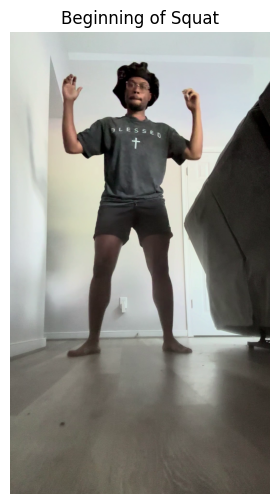

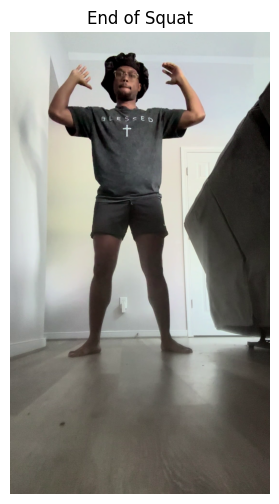

In [22]:
video_path = Path("data/raw/person_02/symmetrical.mp4")

cap = cv2.VideoCapture(str(video_path))

#Find the first frame
cap.set(cv2.CAP_PROP_POS_MSEC, 100)
ret1, first_frame = cap.read()

#Find the last frame
cap.set(cv2.CAP_PROP_POS_MSEC, 2900)
ret2, last_frame = cap.read()

cap.release()

if ret1 and ret2:

    first_rgb = cv2.cvtColor(first_frame, cv2.COLOR_BGR2RGB)
    last_rgb = cv2.cvtColor(last_frame, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(10, 6))
    plt.imshow(first_rgb)
    plt.title("Beginning of Squat")
    plt.axis("off")
    plt.show()

    plt.figure(figsize=(10, 6))
    plt.imshow(last_rgb)
    plt.title("End of Squat")
    plt.axis("off")
    plt.show()

In [173]:
print(df.columns.tolist())
print(df.shape)

['frame', 'time', 'landmark_0_x', 'landmark_0_y', 'landmark_0_z', 'landmark_0_visibility', 'landmark_1_x', 'landmark_1_y', 'landmark_1_z', 'landmark_1_visibility', 'landmark_2_x', 'landmark_2_y', 'landmark_2_z', 'landmark_2_visibility', 'landmark_3_x', 'landmark_3_y', 'landmark_3_z', 'landmark_3_visibility', 'landmark_4_x', 'landmark_4_y', 'landmark_4_z', 'landmark_4_visibility', 'landmark_5_x', 'landmark_5_y', 'landmark_5_z', 'landmark_5_visibility', 'landmark_6_x', 'landmark_6_y', 'landmark_6_z', 'landmark_6_visibility', 'landmark_7_x', 'landmark_7_y', 'landmark_7_z', 'landmark_7_visibility', 'landmark_8_x', 'landmark_8_y', 'landmark_8_z', 'landmark_8_visibility', 'landmark_9_x', 'landmark_9_y', 'landmark_9_z', 'landmark_9_visibility', 'landmark_10_x', 'landmark_10_y', 'landmark_10_z', 'landmark_10_visibility', 'landmark_11_x', 'landmark_11_y', 'landmark_11_z', 'landmark_11_visibility', 'left_shoulder_x', 'left_shoulder_y', 'left_shoulder_z', 'left_shoulder_visibility', 'landmark_12_

Build the master data set

In [11]:
all_features = []

for video_path in video_files:

    print(f"\nProcessing: {video_path}")

    # 1. Extract landmarks
    df = process_video(video_path)

    # 2. Calculate angles
    df = calculate_angles(df)

    # 3. Calculate velocities
    df = calculate_velocity(df)

    # 4. Extract one feature vector
    features = extract_features(
        df,
        person_id=video_path.parent.name,
        condition=video_path.stem
    )

    all_features.append(features)


# Combine every video into one DataFrame
feature_df = pd.concat(
    all_features,
    ignore_index=True
)

print("\nFinal feature dataset shape:", feature_df.shape)

display(feature_df)


Processing: data\raw\person_01\asymmetrical.mp4
FPS: 30.0
FPS: 30.0
Number of frames: 103
Approximate duration processed: 3.433333333333333
DataFrame shape: (103, 182)
Frames processed: 103
Frames with pose: 103

Processing: data\raw\person_01\symmetrical.mp4
FPS: 30.0
FPS: 30.0
Number of frames: 157
Approximate duration processed: 5.233333333333333
DataFrame shape: (93, 182)
Frames processed: 157
Frames with pose: 93

Processing: data\raw\person_02\asymmetrical.mp4
FPS: 30.0
FPS: 30.0
Number of frames: 103
Approximate duration processed: 3.433333333333333
DataFrame shape: (103, 182)
Frames processed: 103
Frames with pose: 103

Processing: data\raw\person_02\symmetrical.mp4
FPS: 30.0
FPS: 30.0
Number of frames: 90
Approximate duration processed: 3.0
DataFrame shape: (90, 182)
Frames processed: 90
Frames with pose: 90

Processing: data\raw\person_04\asymmetrical.mp4
FPS: 30.0
FPS: 30.0
Number of frames: 93
Approximate duration processed: 3.1
DataFrame shape: (93, 182)
Frames processed:

,person_id,condition,left_knee_rom,right_knee_rom,left_hip_rom,right_hip_rom,left_ankle_rom,right_ankle_rom,max_trunk_angle,min_trunk_angle,...,left_ankle_peak_velocity,right_ankle_peak_velocity,peak_trunk_velocity,movement_duration,knee_rom_asymmetry,hip_rom_asymmetry,ankle_rom_asymmetry,knee_velocity_asymmetry,hip_velocity_asymmetry,ankle_velocity_asymmetry
0,person_01,asymmetrical,109.782174,102.580514,138.119907,133.450983,65.033275,60.045719,66.502809,15.351135,...,669.221428,798.137069,726.121711,3.400000,6.782416,3.438457,7.975050,6.775065,6.742447,17.571117
1,person_01,symmetrical,80.370136,121.060848,119.135789,114.959401,71.917885,59.131395,65.643108,7.398729,...,939.975656,1037.508873,706.439349,3.066667,40.401642,3.568111,19.514018,11.300818,11.144258,9.864372
2,person_02,asymmetrical,109.782174,102.580514,138.119907,133.450983,65.033275,60.045719,66.502809,15.351135,...,669.221428,798.137069,726.121711,3.400000,6.782416,3.438457,7.975050,6.775065,6.742447,17.571117
3,person_02,symmetrical,123.352349,120.966673,131.701022,126.255951,69.866541,65.183883,66.406593,1.541631,...,426.337782,568.295336,814.286652,2.966667,1.952919,4.221690,6.934680,28.034955,22.796552,28.544707
4,person_04,asymmetrical,117.114367,127.807467,134.494785,151.066143,80.012634,70.860939,81.928330,17.842401,...,1622.778538,866.781297,660.890163,3.066667,8.731847,11.606180,12.131608,15.133611,30.240763,60.733406
5,person_04,symmetrical,105.763140,128.163066,138.676636,133.769653,56.498957,57.334068,72.909528,4.757445,...,942.587958,578.628350,1297.631584,3.133333,19.151276,3.602165,1.467257,43.284521,7.980531,47.851132


Confirm that the algorithm is separating the videos by condition

In [12]:
print(feature_df.shape)

print(feature_df["condition"].value_counts())

display(
    feature_df[["person_id", "condition"]]
)

print("Dataset shape:", feature_df.shape)

print("\nCondition counts:")
print(feature_df["condition"].value_counts())

print("\nMissing values:")
print(feature_df.isnull().sum())

display(feature_df.head())

print("\nData types:")
print(feature_df.dtypes)

(6, 25)
condition
asymmetrical    3
symmetrical     3
Name: count, dtype: int64


,person_id,condition
0,person_01,asymmetrical
1,person_01,symmetrical
2,person_02,asymmetrical
3,person_02,symmetrical
4,person_04,asymmetrical
5,person_04,symmetrical


Dataset shape: (6, 25)

Condition counts:
condition
asymmetrical    3
symmetrical     3
Name: count, dtype: int64

Missing values:
person_id                    0
condition                    0
left_knee_rom                0
right_knee_rom               0
left_hip_rom                 0
right_hip_rom                0
left_ankle_rom               0
right_ankle_rom              0
max_trunk_angle              0
min_trunk_angle              0
trunk_rom                    0
left_knee_peak_velocity      0
right_knee_peak_velocity     0
left_hip_peak_velocity       0
right_hip_peak_velocity      0
left_ankle_peak_velocity     0
right_ankle_peak_velocity    0
peak_trunk_velocity          0
movement_duration            0
knee_rom_asymmetry           0
hip_rom_asymmetry            0
ankle_rom_asymmetry          0
knee_velocity_asymmetry      0
hip_velocity_asymmetry       0
ankle_velocity_asymmetry     0
dtype: int64


,person_id,condition,left_knee_rom,right_knee_rom,left_hip_rom,right_hip_rom,left_ankle_rom,right_ankle_rom,max_trunk_angle,min_trunk_angle,...,left_ankle_peak_velocity,right_ankle_peak_velocity,peak_trunk_velocity,movement_duration,knee_rom_asymmetry,hip_rom_asymmetry,ankle_rom_asymmetry,knee_velocity_asymmetry,hip_velocity_asymmetry,ankle_velocity_asymmetry
0,person_01,asymmetrical,109.782174,102.580514,138.119907,133.450983,65.033275,60.045719,66.502809,15.351135,...,669.221428,798.137069,726.121711,3.400000,6.782416,3.438457,7.975050,6.775065,6.742447,17.571117
1,person_01,symmetrical,80.370136,121.060848,119.135789,114.959401,71.917885,59.131395,65.643108,7.398729,...,939.975656,1037.508873,706.439349,3.066667,40.401642,3.568111,19.514018,11.300818,11.144258,9.864372
2,person_02,asymmetrical,109.782174,102.580514,138.119907,133.450983,65.033275,60.045719,66.502809,15.351135,...,669.221428,798.137069,726.121711,3.400000,6.782416,3.438457,7.975050,6.775065,6.742447,17.571117
3,person_02,symmetrical,123.352349,120.966673,131.701022,126.255951,69.866541,65.183883,66.406593,1.541631,...,426.337782,568.295336,814.286652,2.966667,1.952919,4.221690,6.934680,28.034955,22.796552,28.544707
4,person_04,asymmetrical,117.114367,127.807467,134.494785,151.066143,80.012634,70.860939,81.928330,17.842401,...,1622.778538,866.781297,660.890163,3.066667,8.731847,11.606180,12.131608,15.133611,30.240763,60.733406



Data types:
person_id                     object
condition                     object
left_knee_rom                float64
right_knee_rom               float64
left_hip_rom                 float64
right_hip_rom                float64
left_ankle_rom               float64
right_ankle_rom              float64
max_trunk_angle              float64
min_trunk_angle              float64
trunk_rom                    float64
left_knee_peak_velocity      float64
right_knee_peak_velocity     float64
left_hip_peak_velocity       float64
right_hip_peak_velocity      float64
left_ankle_peak_velocity     float64
right_ankle_peak_velocity    float64
peak_trunk_velocity          float64
movement_duration            float64
knee_rom_asymmetry           float64
hip_rom_asymmetry            float64
ankle_rom_asymmetry          float64
knee_velocity_asymmetry      float64
hip_velocity_asymmetry       float64
ankle_velocity_asymmetry     float64
dtype: object


Set up y variable for testing

In [13]:
symmetrical = 0
asymmetrical = 1

Verify that each person has both coniditions and that the classes are balanced

In [14]:
print(
    feature_df.groupby("person_id")["condition"]
    .value_counts()
)

print(feature_df["condition"].value_counts())

person_id  condition   
person_01  asymmetrical    1
           symmetrical     1
person_02  asymmetrical    1
           symmetrical     1
person_04  asymmetrical    1
           symmetrical     1
Name: count, dtype: int64
condition
asymmetrical    3
symmetrical     3
Name: count, dtype: int64


Set up x, y, and group variables for testing

In [15]:
# Target variable
y = feature_df["condition"].map({
    "symmetrical": 0,
    "asymmetrical": 1
})

# Participant groups
groups = feature_df["person_id"]

# Feature matrix
X = feature_df.drop(
    columns=["person_id", "condition"]
)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Number of people:", groups.nunique())

display(X.head())
print(y)

X shape: (6, 23)
y shape: (6,)
Number of people: 3


,left_knee_rom,right_knee_rom,left_hip_rom,right_hip_rom,left_ankle_rom,right_ankle_rom,max_trunk_angle,min_trunk_angle,trunk_rom,left_knee_peak_velocity,...,left_ankle_peak_velocity,right_ankle_peak_velocity,peak_trunk_velocity,movement_duration,knee_rom_asymmetry,hip_rom_asymmetry,ankle_rom_asymmetry,knee_velocity_asymmetry,hip_velocity_asymmetry,ankle_velocity_asymmetry
0,109.782174,102.580514,138.119907,133.450983,65.033275,60.045719,66.502809,15.351135,51.151674,740.728276,...,669.221428,798.137069,726.121711,3.400000,6.782416,3.438457,7.975050,6.775065,6.742447,17.571117
1,80.370136,121.060848,119.135789,114.959401,71.917885,59.131395,65.643108,7.398729,58.244379,939.322862,...,939.975656,1037.508873,706.439349,3.066667,40.401642,3.568111,19.514018,11.300818,11.144258,9.864372
2,109.782174,102.580514,138.119907,133.450983,65.033275,60.045719,66.502809,15.351135,51.151674,740.728276,...,669.221428,798.137069,726.121711,3.400000,6.782416,3.438457,7.975050,6.775065,6.742447,17.571117
3,123.352349,120.966673,131.701022,126.255951,69.866541,65.183883,66.406593,1.541631,64.864962,745.423589,...,426.337782,568.295336,814.286652,2.966667,1.952919,4.221690,6.934680,28.034955,22.796552,28.544707
4,117.114367,127.807467,134.494785,151.066143,80.012634,70.860939,81.928330,17.842401,64.085929,1918.934944,...,1622.778538,866.781297,660.890163,3.066667,8.731847,11.606180,12.131608,15.133611,30.240763,60.733406


0    1
1    0
2    1
3    0
4    1
5    0
Name: condition, dtype: int64


START THE MACHINE LEARNING

In [17]:
from sklearn.model_selection import StratifiedGroupKFold

cv = StratifiedGroupKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

Use Logistic regression as a baseline method within the cross validation process to make sure test participant information is not leaked into training information

In [18]:
for fold, (train_idx, test_idx) in enumerate(
    cv.split(X, y, groups=groups),
    start=1
):

    train_people = groups.iloc[train_idx].unique()
    test_people = groups.iloc[test_idx].unique()

    print(f"\nFold {fold}")

    print("Train people:", train_people)
    print("Test people:", test_people)

    print("Train samples:", len(train_idx))
    print("Test samples:", len(test_idx))

    print("Test conditions:")
    print(y.iloc[test_idx].value_counts())


Fold 1
Train people: ['person_02' 'person_04']
Test people: ['person_01']
Train samples: 4
Test samples: 2
Test conditions:
condition
1    1
0    1
Name: count, dtype: int64

Fold 2
Train people: ['person_01' 'person_04']
Test people: ['person_02']
Train samples: 4
Test samples: 2
Test conditions:
condition
1    1
0    1
Name: count, dtype: int64

Fold 3
Train people: ['person_01' 'person_02']
Test people: ['person_04']
Train samples: 4
Test samples: 2
Test conditions:
condition
1    1
0    1
Name: count, dtype: int64


In [19]:
from sklearn.model_selection import cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000, random_state=42))
])

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1"
}

results = cross_validate(
    logistic_model, X, y,
    cv=cv, groups=groups,
    scoring=scoring,
    return_train_score=False
)

for metric in scoring:
    
    scores = results[f"test_{metric}"]
    
    print(
        f"{metric.capitalize()}: "
        f"{scores.mean():.3f} ± {scores.std():.3f}"
    )

    print("Fold scores:", scores)
    print()

Accuracy: 0.667 ± 0.236
Fold scores: [0.5 1.  0.5]

Precision: 0.667 ± 0.236
Fold scores: [0.5 1.  0.5]

Recall: 1.000 ± 0.000
Fold scores: [1. 1. 1.]

F1: 0.778 ± 0.157
Fold scores: [0.66666667 1.         0.66666667]



In [233]:
pip install xgboost

  Using cached xgboost-3.2.0-py3-none-win_amd64.whl.metadata (2.1 kB)
Using cached xgboost-3.2.0-py3-none-win_amd64.whl (101.7 MB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: C:\Users\bluek\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [20]:
from xgboost import XGBClassifier

In [21]:
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

xgb_results = cross_validate(
    xgb_model,
    X,
    y,
    cv=cv,
    groups=groups,
    scoring=scoring,
    return_train_score=False
)

for metric in scoring:

    scores = xgb_results[f"test_{metric}"]

    print(
        f"{metric.capitalize()}: "
        f"{scores.mean():.3f} ± {scores.std():.3f}"
    )

    print("Fold scores:", scores)
    print()

Accuracy: 0.500 ± 0.000
Fold scores: [0.5 0.5 0.5]

Precision: 0.000 ± 0.000
Fold scores: [0. 0. 0.]

Recall: 0.000 ± 0.000
Fold scores: [0. 0. 0.]

F1: 0.000 ± 0.000
Fold scores: [0. 0. 0.]



C:\Users\bluek\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\bluek\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\bluek\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:17

In [213]:
video_path = Path("data/raw/person_02/symmetrical.mp4")

df = process_video(video_path)
df = calculate_angles(df)
df = calculate_velocity(df)

features = extract_features(
    df,
    person_id=video_path.parent.name,
    condition=video_path.stem
)

print(features.shape)
display(features)

FPS: 30.0
FPS: 30.0
Number of frames: 90
Approximate duration processed: 3.0
DataFrame shape: (90, 182)
Frames processed: 90
Frames with pose: 90
(1, 25)


,person_id,condition,left_knee_rom,right_knee_rom,left_hip_rom,right_hip_rom,left_ankle_rom,right_ankle_rom,max_trunk_angle,min_trunk_angle,...,left_ankle_peak_velocity,right_ankle_peak_velocity,peak_trunk_velocity,movement_duration,knee_rom_asymmetry,hip_rom_asymmetry,ankle_rom_asymmetry,knee_velocity_asymmetry,hip_velocity_asymmetry,ankle_velocity_asymmetry
0,person_02,symmetrical,123.352349,120.966673,131.701022,126.255951,69.866541,65.183883,66.406593,1.541631,...,426.337782,568.295336,814.286652,2.966667,1.952919,4.22169,6.93468,28.034955,22.796552,28.544707


In [210]:
all_features = []

for video_path in video_files:

    print(f"\nProcessing: {video_path}")

    # Raw landmarks
    df = process_video(video_path)

    # Joint angles
    df = calculate_angles(df)

    # Angular velocities
    df = calculate_velocity(df)

    # Feature vector
    features = extract_features(
        df,
        person_id=video_path.parent.name,
        condition=video_path.stem
    )

    all_features.append(features)


Processing: data\raw\person_01\symmetrical.mp4
FPS: 30.0
FPS: 30.0
Number of frames: 157
Approximate duration processed: 5.233333333333333
DataFrame shape: (93, 182)
Frames processed: 157
Frames with pose: 93

Processing: data\raw\person_02\symmetrical.mp4
FPS: 30.0
FPS: 30.0
Number of frames: 90
Approximate duration processed: 3.0
DataFrame shape: (90, 182)
Frames processed: 90
Frames with pose: 90


In [211]:
feature_df = pd.concat(
    all_features,
    ignore_index=True
)

In [212]:
print(feature_df.shape)
print(feature_df.head())

(2, 25)
   person_id    condition  left_knee_rom  right_knee_rom  left_hip_rom  \
0  person_01  symmetrical      80.370136      121.060848    119.135789   
1  person_02  symmetrical     123.352349      120.966673    131.701022   

   right_hip_rom  left_ankle_rom  right_ankle_rom  max_trunk_angle  \
0     114.959401       71.917885        59.131395        65.643108   
1     126.255951       69.866541        65.183883        66.406593   

   min_trunk_angle  ...  left_ankle_peak_velocity  right_ankle_peak_velocity  \
0         7.398729  ...                939.975656                1037.508873   
1         1.541631  ...                426.337782                 568.295336   

   peak_trunk_velocity  movement_duration  knee_rom_asymmetry  \
0           706.439349           3.066667           40.401642   
1           814.286652           2.966667            1.952919   

   hip_rom_asymmetry  ankle_rom_asymmetry  knee_velocity_asymmetry  \
0           3.568111            19.514018          

Create a function that calculates joint angle detection on all joints

In [ ]:
import numpy as np

def calculate_angle(a, b, c):
    """
   Calculate angle ABC in degrees.
    
    a = first point
    b = vertex
    c = third point
    """

    a = np.array(a)
    b = np.array(b)
    c = np.array(c)

    ba = a - b
    bc = c - b

    cosine_angle = np.dot(ba, bc) / (
        np.linalg.norm(ba) * np.linalg.norm(bc)
    )

    cosine_angle = np.clip(cosine_angle, -1.0, 1.0)

    angle = np.degrees(np.arccos(cosine_angle))

    return angle

In [204]:
df["shoulder_center_x"] = (
    df["left_shoulder_x"] +
    df["right_shoulder_x"]
) / 2

df["shoulder_center_y"] = (
    df["left_shoulder_y"] +
    df["right_shoulder_y"]
) / 2

df["shoulder_center_z"] = (
    df["left_shoulder_z"] +
    df["right_shoulder_z"]
) / 2


df["hip_center_x"] = (
    df["left_hip_x"] +
    df["right_hip_x"]
) / 2

df["hip_center_y"] = (
    df["left_hip_y"] +
    df["right_hip_y"]
) / 2

df["hip_center_z"] = (
    df["left_hip_z"] +
    df["right_hip_z"]
) / 2

def calculate_angles(df):

    #KNEES
    df["left_knee_angle"] = df.apply(
        lambda row: calculate_angle(
            [row["left_hip_x"], row["left_hip_y"], row["left_hip_z"]],
            [row["left_knee_x"], row["left_knee_y"], row["left_knee_z"]],
            [row["left_ankle_x"], row["left_ankle_y"], row["left_ankle_z"]]
        ),
        axis=1
    )

    df["right_knee_angle"] = df.apply(
        lambda row: calculate_angle(
            [row["right_hip_x"], row["right_hip_y"], row["right_hip_z"]],
            [row["right_knee_x"], row["right_knee_y"], row["right_knee_z"]],
            [row["right_ankle_x"], row["right_ankle_y"], row["right_ankle_z"]]
        ),
        axis=1
    )

    #HIPS
    df["left_hip_angle"] = df.apply(
        lambda row: calculate_angle(
            [row["left_shoulder_x"], row["left_shoulder_y"], row["left_shoulder_z"]],
            [row["left_hip_x"], row["left_hip_y"], row["left_hip_z"]],
            [row["left_knee_x"], row["left_knee_y"], row["left_knee_z"]]
        ),
        axis=1
    )

    df["right_hip_angle"] = df.apply(
        lambda row: calculate_angle(
            [row["right_shoulder_x"], row["right_shoulder_y"], row["right_shoulder_z"]],
            [row["right_hip_x"], row["right_hip_y"], row["right_hip_z"]],
            [row["right_knee_x"], row["right_knee_y"], row["right_knee_z"]]
        ),
        axis=1
    )

    #ANKLES
    df["left_ankle_angle"] = df.apply(
        lambda row: calculate_angle(
            [row["left_knee_x"], row["left_knee_y"], row["left_knee_z"]],
            [row["left_ankle_x"], row["left_ankle_y"], row["left_ankle_z"]],
            [row["left_foot_index_x"], row["left_foot_index_y"], row["left_foot_index_z"]]
        ),
        axis=1
    )

    df["right_ankle_angle"] = df.apply(
        lambda row: calculate_angle(
            [row["right_knee_x"], row["right_knee_y"], row["right_knee_z"]],
            [row["right_ankle_x"], row["right_ankle_y"], row["right_ankle_z"]],
            [row["right_foot_index_x"], row["right_foot_index_y"], row["right_foot_index_z"]]
        ),
        axis=1
    )


    df["trunk_vector_x"] = (
    df["shoulder_center_x"] - df["hip_center_x"]
    )

    df["trunk_vector_y"] = (
    df["shoulder_center_y"] - df["hip_center_y"]
    )

    df["trunk_vector_z"] = (
    df["shoulder_center_z"] - df["hip_center_z"]
    )

    df["trunk_angle"] = df.apply(
        lambda row: vector_angle(
            [
                row["trunk_vector_x"],
                row["trunk_vector_y"],
                row["trunk_vector_z"]
            ],
            vertical
        ),
        axis=1
    )

    df[["frame", "time", "left_knee_angle", "right_knee_angle", "left_hip_angle", "right_hip_angle",
        "left_ankle_angle", "right_ankle_angle",]].head(10)

    return df

In [ ]:
def calculate_velocity(df):

    df["left_knee_angular_velocity"] = (
        df["left_knee_angle"].diff() / df["time"].diff()
    )

    df["right_knee_angular_velocity"] = (
        df["right_knee_angle"].diff() / df["time"].diff()
    )

    df["left_hip_angular_velocity"] = (
        df["left_hip_angle"].diff() / df["time"].diff()
    )

    df["right_hip_angular_velocity"] = (
        df["right_hip_angle"].diff() / df["time"].diff()
    )

    df["left_ankle_angular_velocity"] = (
        df["left_ankle_angle"].diff() / df["time"].diff()
    )

    df["right_ankle_angular_velocity"] = (
        df["right_ankle_angle"].diff() / df["time"].diff()
    )

    df["trunk_angular_velocity"] = (
        df["trunk_angle"].diff() / df["time"].diff()
    )

    return df

In [ ]:
    #Knee ROM
    left_knee_rom = (
        df["left_knee_angle"].max() -
        df["left_knee_angle"].min()
    )

    right_knee_rom = (
        df["right_knee_angle"].max() -
        df["right_knee_angle"].min()
    )

    #Hip ROM
    left_hip_rom = (
        df["left_hip_angle"].max() -
        df["left_hip_angle"].min()
    )

    right_hip_rom = (
        df["right_hip_angle"].max() -
        df["right_hip_angle"].min()
    )

    #Ankle ROM
    left_ankle_rom = (
        df["left_ankle_angle"].max() -
        df["left_ankle_angle"].min()
    )

    right_ankle_rom = (
        df["right_ankle_angle"].max() -
        df["right_ankle_angle"].min()
    )

    print("Left knee ROM:", left_knee_rom)
    print("Right knee ROM:", right_knee_rom)
    print("")
    print("Left hip ROM:", left_hip_rom)
    print("Right hip ROM:", right_hip_rom)
    print("")
    print("Left ankle ROM:", left_ankle_rom)
    print("Right ankle ROM:", right_ankle_rom)
    print("")
    print(
        "Knee ROM difference:", abs(left_knee_rom - right_knee_rom)
    )

    print(
        "Hip ROM difference:", abs(left_hip_rom - right_hip_rom)
    )

    print(
        "Ankle ROM difference:", abs(left_ankle_rom - right_ankle_rom)
    )

    knee_rom_asymmetry = asymmetry_percentage(
    left_knee_rom,
    right_knee_rom
    )

    hip_rom_asymmetry = asymmetry_percentage(
    left_hip_rom,
    right_hip_rom
    )

    ankle_rom_asymmetry = asymmetry_percentage(
    left_ankle_rom,
    right_ankle_rom
    )

    print("Knee ROM asymmetry:", knee_rom_asymmetry, "%")
    print("Hip ROM asymmetry:", hip_rom_asymmetry, "%")
    print("Ankle ROM asymmetry:", ankle_rom_asymmetry, "%")

    left_knee_peak_velocity = (
        df["left_knee_angular_velocity"].abs().max()
    )

    right_knee_peak_velocity = (
        df["right_knee_angular_velocity"].abs().max()
    )

    left_hip_peak_velocity = (
        df["left_hip_angular_velocity"].abs().max()
    )

    right_hip_peak_velocity = (
        df["right_hip_angular_velocity"].abs().max()
    )

    left_ankle_peak_velocity = (
        df["left_ankle_angular_velocity"].abs().max()
    )

    right_ankle_peak_velocity = (
        df["right_ankle_angular_velocity"].abs().max()
    )

    peak_trunk_velocity = (
        df["trunk_angular_velocity"].abs().max()
    )

    knee_velocity_asymmetry = asymmetry_percentage(
        left_knee_peak_velocity, right_knee_peak_velocity
    )

    hip_velocity_asymmetry = asymmetry_percentage(
        left_hip_peak_velocity, right_hip_peak_velocity
    )

    ankle_velocity_asymmetry = asymmetry_percentage(
        left_ankle_peak_velocity, right_ankle_peak_velocity
    )

    movement_duration = df["time"].max() - df["time"].min()

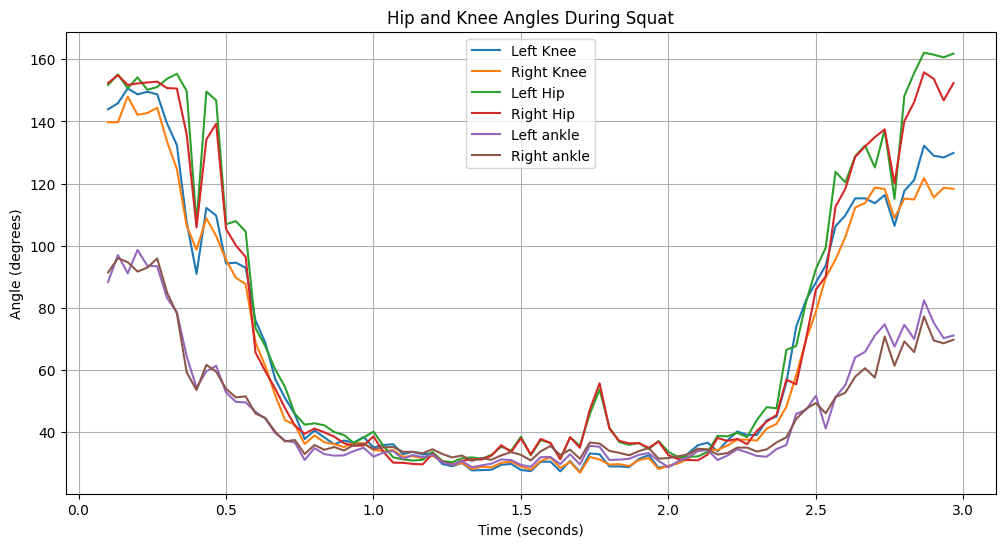

In [176]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.plot(
    df["time"],
    df["left_knee_angle"],
    label="Left Knee"
)

plt.plot(
    df["time"],
    df["right_knee_angle"],
    label="Right Knee"
)

plt.plot(
    df["time"],
    df["left_hip_angle"],
    label="Left Hip"
)

plt.plot(
    df["time"],
    df["right_hip_angle"],
    label="Right Hip"
)

plt.plot(
    df["time"],
    df["left_ankle_angle"],
    label="Left ankle"
)

plt.plot(
    df["time"],
    df["right_ankle_angle"],
    label="Right ankle"
)

plt.xlabel("Time (seconds)")
plt.ylabel("Angle (degrees)")
plt.title("Hip and Knee Angles During Squat")
plt.legend()
plt.grid(True)

plt.show()

Calculate the range of motion for each joint

In [177]:
#Knee ROM
left_knee_rom = (
    df["left_knee_angle"].max() -
    df["left_knee_angle"].min()
)

right_knee_rom = (
    df["right_knee_angle"].max() -
    df["right_knee_angle"].min()
)

#Hip ROM
left_hip_rom = (
    df["left_hip_angle"].max() -
    df["left_hip_angle"].min()
)

right_hip_rom = (
    df["right_hip_angle"].max() -
    df["right_hip_angle"].min()
)

#Ankle ROM
left_ankle_rom = (
    df["left_ankle_angle"].max() -
    df["left_ankle_angle"].min()
)

right_ankle_rom = (
    df["right_ankle_angle"].max() -
    df["right_ankle_angle"].min()
)

print("Left knee ROM:", left_knee_rom)
print("Right knee ROM:", right_knee_rom)
print("")
print("Left hip ROM:", left_hip_rom)
print("Right hip ROM:", right_hip_rom)
print("")
print("Left ankle ROM:", left_ankle_rom)
print("Right ankle ROM:", right_ankle_rom)
print("")
print(
    "Knee ROM difference:",
    abs(left_knee_rom - right_knee_rom)
)

print(
    "Hip ROM difference:",
    abs(left_hip_rom - right_hip_rom)
)

print(
    "Ankle ROM difference:",
    abs(left_ankle_rom - right_ankle_rom)
)

Left knee ROM: 123.35234921535401
Right knee ROM: 120.96667337009119

Left hip ROM: 131.7010220293339
Right hip ROM: 126.25595054886092

Left ankle ROM: 69.86654075788789
Right ankle ROM: 65.18388317383412

Knee ROM difference: 2.385675845262824
Hip ROM difference: 5.445071480472976
Ankle ROM difference: 4.682657584053771


Normalized Asymmetry

In [178]:
def asymmetry_percentage(left, right):
    return (
        abs(left - right) /
        ((left + right) / 2)
    ) * 100

knee_rom_asymmetry = asymmetry_percentage(
    left_knee_rom,
    right_knee_rom
)

hip_rom_asymmetry = asymmetry_percentage(
    left_hip_rom,
    right_hip_rom
)

ankle_rom_asymmetry = asymmetry_percentage(
    left_ankle_rom,
    right_ankle_rom
)

print("Knee ROM asymmetry:", knee_rom_asymmetry, "%")
print("Hip ROM asymmetry:", hip_rom_asymmetry, "%")
print("Ankle ROM asymmetry:", ankle_rom_asymmetry, "%")

Knee ROM asymmetry: 1.9529186225591473 %
Hip ROM asymmetry: 4.221689707435533 %
Ankle ROM asymmetry: 6.93468031825091 %


Display the joint angles during the squat

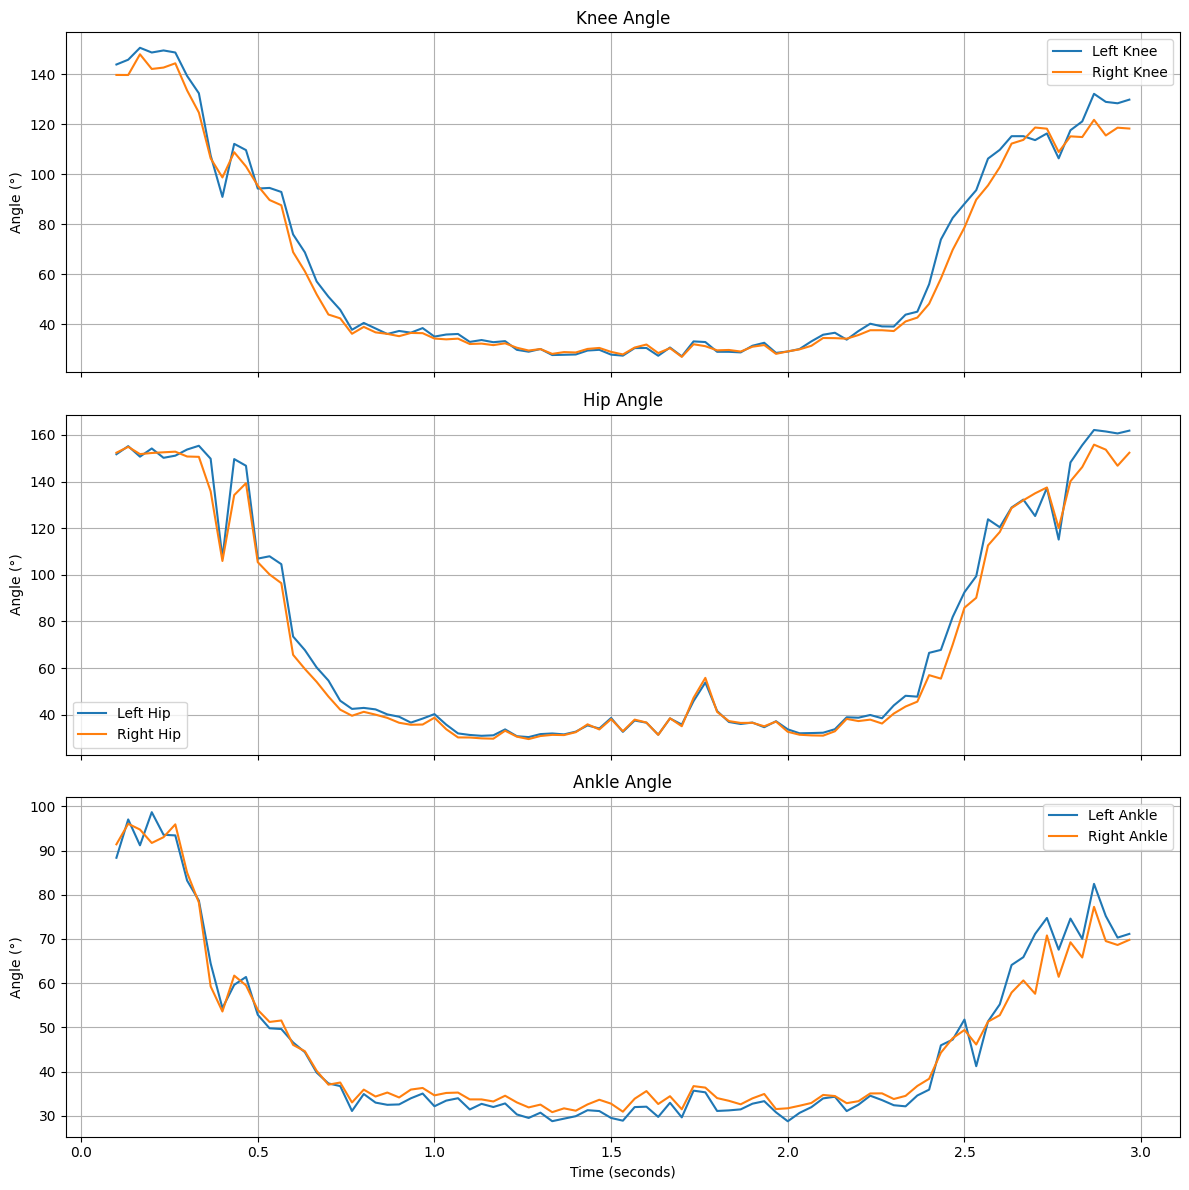

In [179]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 1, figsize=(12, 12), sharex=True)

# Knee
axes[0].plot(
    df["time"],
    df["left_knee_angle"],
    label="Left Knee"
)

axes[0].plot(
    df["time"],
    df["right_knee_angle"],
    label="Right Knee"
)

axes[0].set_ylabel("Angle (°)")
axes[0].set_title("Knee Angle")
axes[0].legend()
axes[0].grid(True)

# Hip
axes[1].plot(
    df["time"],
    df["left_hip_angle"],
    label="Left Hip"
)

axes[1].plot(
    df["time"],
    df["right_hip_angle"],
    label="Right Hip"
)

axes[1].set_ylabel("Angle (°)")
axes[1].set_title("Hip Angle")
axes[1].legend()
axes[1].grid(True)

# Ankle
axes[2].plot(
    df["time"],
    df["left_ankle_angle"],
    label="Left Ankle"
)

axes[2].plot(
    df["time"],
    df["right_ankle_angle"],
    label="Right Ankle"
)

axes[2].set_xlabel("Time (seconds)")
axes[2].set_ylabel("Angle (°)")
axes[2].set_title("Ankle Angle")
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.show()

Identify the Y coordinate

In [180]:
print(df[[
    "left_shoulder_x",
    "left_shoulder_y",
    "left_shoulder_z",
    "left_hip_x",
    "left_hip_y",
    "left_hip_z"
]].head())

print(df[[
    "right_shoulder_x",
    "right_shoulder_y",
    "right_shoulder_z",
    "right_hip_x",
    "right_hip_y",
    "right_hip_z"
]].head())

   left_shoulder_x  left_shoulder_y  left_shoulder_z  left_hip_x  left_hip_y  \
0         0.603951         0.213742         0.119842    0.549644    0.380336   
1         0.601893         0.212512         0.130078    0.547866    0.379842   
2         0.599792         0.212464         0.104598    0.544518    0.380300   
3         0.598535         0.209974         0.136638    0.546073    0.377074   
4         0.596841         0.207992         0.131694    0.542539    0.379379   

   left_hip_z  
0    0.008446  
1    0.010214  
2   -0.002902  
3    0.005300  
4   -0.001117  
   right_shoulder_x  right_shoulder_y  right_shoulder_z  right_hip_x  \
0          0.375512          0.202614          0.111711     0.410155   
1          0.373314          0.203811          0.116300     0.408784   
2          0.371161          0.201747          0.109912     0.406498   
3          0.367641          0.200865          0.132197     0.405382   
4          0.366242          0.199412          0.139224     0.4

Calculate the torso center points with a hip and shoulder center point

In [182]:
import numpy as np

df["shoulder_center_x"] = (
    df["left_shoulder_x"] +
    df["right_shoulder_x"]
) / 2

df["shoulder_center_y"] = (
    df["left_shoulder_y"] +
    df["right_shoulder_y"]
) / 2

df["shoulder_center_z"] = (
    df["left_shoulder_z"] +
    df["right_shoulder_z"]
) / 2


df["hip_center_x"] = (
    df["left_hip_x"] +
    df["right_hip_x"]
) / 2

df["hip_center_y"] = (
    df["left_hip_y"] +
    df["right_hip_y"]
) / 2

df["hip_center_z"] = (
    df["left_hip_z"] +
    df["right_hip_z"]
) / 2

df[[
    "shoulder_center_x",
    "shoulder_center_y",
    "shoulder_center_z",
    "hip_center_x",
    "hip_center_y",
    "hip_center_z"
]].head()

,shoulder_center_x,shoulder_center_y,shoulder_center_z,hip_center_x,hip_center_y,hip_center_z
0,0.489731,0.208178,0.115777,0.479899,0.377453,-0.000216
1,0.487603,0.208161,0.123189,0.478325,0.376351,-0.000224
2,0.485476,0.207105,0.107255,0.475508,0.377983,-0.000289
3,0.483088,0.205419,0.134417,0.475728,0.374502,-0.000254
4,0.481542,0.203702,0.135459,0.473181,0.376487,-0.000228


Calculate the trunk lean using the Y coordinate to calculate a vector from the hip center to the shoulder center 

In [ ]:


df["trunk_angle"].head()

0    34.515934
1    36.347198
2    32.295397
3    38.578530
4    38.194936
Name: trunk_angle, dtype: float64

Display trunk angle during squat

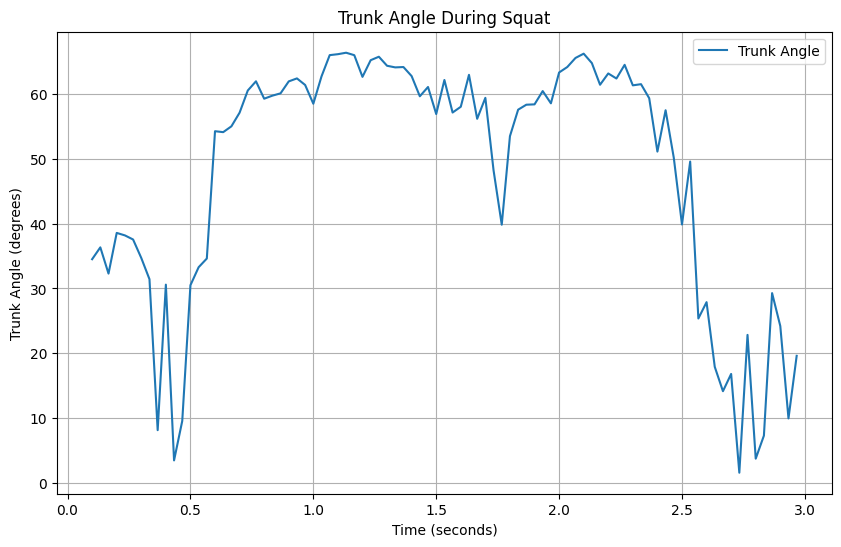

In [186]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.plot(
    df["time"],
    df["trunk_angle"],
    label="Trunk Angle"
)

plt.xlabel("Time (seconds)")
plt.ylabel("Trunk Angle (degrees)")
plt.title("Trunk Angle During Squat")
plt.legend()
plt.grid(True)

plt.show()

Calculate Angular velocity of all joints

In [187]:
df["left_knee_angular_velocity"] = (
    df["left_knee_angle"].diff() /
    df["time"].diff()
)

df["right_knee_angular_velocity"] = (
    df["right_knee_angle"].diff() /
    df["time"].diff()
)

df["left_hip_angular_velocity"] = (
    df["left_hip_angle"].diff() /
    df["time"].diff()
)

df["right_hip_angular_velocity"] = (
    df["right_hip_angle"].diff() /
    df["time"].diff()
)

df["left_ankle_angular_velocity"] = (
    df["left_ankle_angle"].diff() /
    df["time"].diff()
)

df["right_ankle_angular_velocity"] = (
    df["right_ankle_angle"].diff() /
    df["time"].diff()
)

df["trunk_angular_velocity"] = (
    df["trunk_angle"].diff() /
    df["time"].diff()
)

Display knee velocity

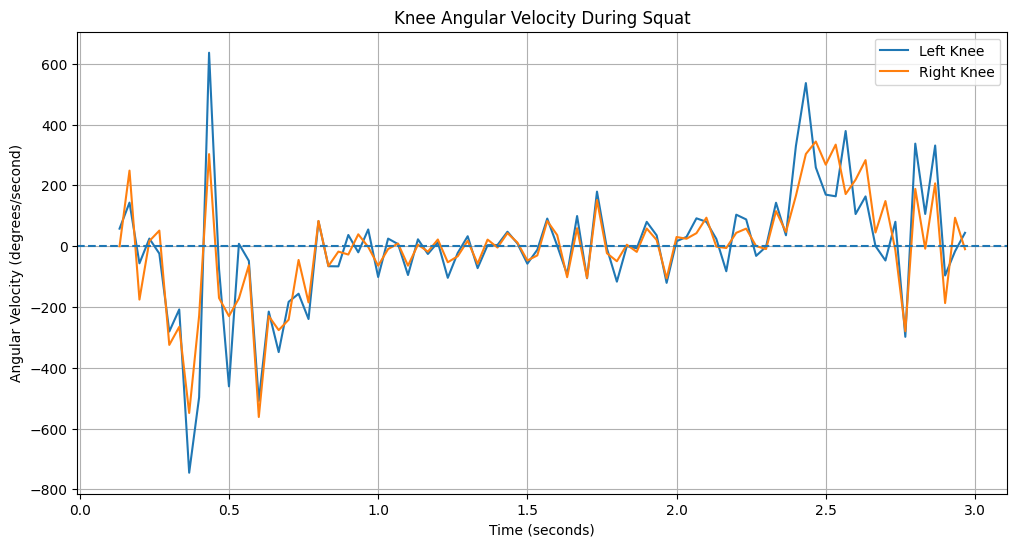

In [188]:
plt.figure(figsize=(12, 6))

plt.plot(
    df["time"],
    df["left_knee_angular_velocity"],
    label="Left Knee"
)

plt.plot(
    df["time"],
    df["right_knee_angular_velocity"],
    label="Right Knee"
)

plt.axhline(0, linestyle="--")

plt.xlabel("Time (seconds)")
plt.ylabel("Angular Velocity (degrees/second)")
plt.title("Knee Angular Velocity During Squat")
plt.legend()
plt.grid(True)

plt.show()

Grab peak absolute angular velocity and velocity asymmetry for each joint

In [ ]:
left_knee_peak_velocity = (
    df["left_knee_angular_velocity"].abs().max()
)

right_knee_peak_velocity = (
    df["right_knee_angular_velocity"].abs().max()
)

left_hip_peak_velocity = (
    df["left_hip_angular_velocity"].abs().max()
)

right_hip_peak_velocity = (
    df["right_hip_angular_velocity"].abs().max()
)

left_ankle_peak_velocity = (
    df["left_ankle_angular_velocity"].abs().max()
)

right_ankle_peak_velocity = (
    df["right_ankle_angular_velocity"].abs().max()
)

peak_trunk_velocity = (
    df["trunk_angular_velocity"].abs().max()
)

knee_velocity_asymmetry = asymmetry_percentage(
    left_knee_peak_velocity,
    right_knee_peak_velocity
)

hip_velocity_asymmetry = asymmetry_percentage(
    left_hip_peak_velocity,
    right_hip_peak_velocity
)

ankle_velocity_asymmetry = asymmetry_percentage(
    left_ankle_peak_velocity,
    right_ankle_peak_velocity
)


Calculate movement duration

In [197]:
movement_duration = df["time"].max() - df["time"].min()

Create a function that will calculate asymmetry

In [198]:
def calculate_asymmetry(left_value, right_value):
    average = (left_value + right_value) / 2

    if average == 0:
        return 0

    return abs(left_value - right_value) / average * 100

Create a function that extracts features into a vector

In [199]:
def extract_features(df, person_id, condition):

    features = {
        "person_id": person_id,
        "condition": condition,

        #KNEE ROM
        "left_knee_rom": (
            df["left_knee_angle"].max()
            - df["left_knee_angle"].min()
        ),

        "right_knee_rom": (
            df["right_knee_angle"].max()
            - df["right_knee_angle"].min()
        ),

        #HIP ROM
        "left_hip_rom": (
            df["left_hip_angle"].max()
            - df["left_hip_angle"].min()
        ),

        "right_hip_rom": (
            df["right_hip_angle"].max()
            - df["right_hip_angle"].min()
        ),

        #ANKLE ROM
        "left_ankle_rom": (
            df["left_ankle_angle"].max()
            - df["left_ankle_angle"].min()
        ),

        "right_ankle_rom": (
            df["right_ankle_angle"].max()
            - df["right_ankle_angle"].min()
        ),

        #TRUNK
        "max_trunk_angle": df["trunk_angle"].max(),

        "min_trunk_angle": df["trunk_angle"].min(),

        "trunk_rom": (
            df["trunk_angle"].max()
            - df["trunk_angle"].min()
        ),

        #VELOCITY
        "left_knee_peak_velocity": (
            df["left_knee_angular_velocity"].abs().max()
        ),

        "right_knee_peak_velocity": (
            df["right_knee_angular_velocity"].abs().max()
        ),

        "left_hip_peak_velocity": (
            df["left_hip_angular_velocity"].abs().max()
        ),

        "right_hip_peak_velocity": (
            df["right_hip_angular_velocity"].abs().max()
        ),

        "left_ankle_peak_velocity": (
            df["left_ankle_angular_velocity"].abs().max()
        ),

        "right_ankle_peak_velocity": (
            df["right_ankle_angular_velocity"].abs().max()
        ),

        "peak_trunk_velocity": (
            df["trunk_angular_velocity"].abs().max()
        ),

        #MOVEMENT TIMING
        "movement_duration": (
            df["time"].max() - df["time"].min()
        )
    }

    #ASYMMETRY FEATURES

    features["knee_rom_asymmetry"] = calculate_asymmetry(
        features["left_knee_rom"],
        features["right_knee_rom"]
    )

    features["hip_rom_asymmetry"] = calculate_asymmetry(
        features["left_hip_rom"],
        features["right_hip_rom"]
    )

    features["ankle_rom_asymmetry"] = calculate_asymmetry(
        features["left_ankle_rom"],
        features["right_ankle_rom"]
    )

    features["knee_velocity_asymmetry"] = calculate_asymmetry(
        features["left_knee_peak_velocity"],
        features["right_knee_peak_velocity"]
    )

    features["hip_velocity_asymmetry"] = calculate_asymmetry(
        features["left_hip_peak_velocity"],
        features["right_hip_peak_velocity"]
    )

    features["ankle_velocity_asymmetry"] = calculate_asymmetry(
        features["left_ankle_peak_velocity"],
        features["right_ankle_peak_velocity"]
    )

    return pd.DataFrame([features])

In [200]:
features_person02 = extract_features(
    df,
    person_id="person_02",
    condition="symmetrical"
)

print(features_person02)
print(features_person02.shape)

   person_id    condition  left_knee_rom  right_knee_rom  left_hip_rom  \
0  person_02  symmetrical     123.352349      120.966673    131.701022   

   right_hip_rom  left_ankle_rom  right_ankle_rom  max_trunk_angle  \
0     126.255951       69.866541        65.183883        66.406593   

   min_trunk_angle  ...  left_ankle_peak_velocity  right_ankle_peak_velocity  \
0         1.541631  ...                426.337782                 568.295336   

   peak_trunk_velocity  movement_duration  knee_rom_asymmetry  \
0           814.286652           2.866667            1.952919   

   hip_rom_asymmetry  ankle_rom_asymmetry  knee_velocity_asymmetry  \
0            4.22169              6.93468                28.034955   

   hip_velocity_asymmetry  ankle_velocity_asymmetry  
0               22.796552                 28.544707  

[1 rows x 25 columns]
(1, 25)


Frame successfully read: True
Frame shape: (1920, 1080, 3)


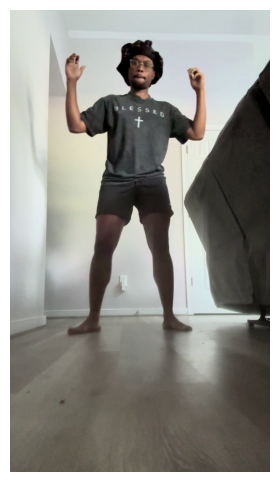

In [ ]:
import cv2
import matplotlib.pyplot as plt
from pathlib import Path

video_path = Path("data/raw/person_02/symmetrical.mp4")

video_files = list(Path("data/raw").rglob("*.mp4"))

for video in video_files:
    print(video)

def process_video(video):

    return video

person_id = video_path.parent.name
condition = video_path.stem

video_path = "data/raw/person_02/symmetrical.mp4"

cap = cv2.VideoCapture(video_path)

ret, frame = cap.read()

cap.release()

print("Frame successfully read:", ret)
print("Frame shape:", frame.shape if ret else None)

if ret:
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(10, 6))
    plt.imshow(frame_rgb)
    plt.axis("off")
    plt.show()

Frame read successfully: True


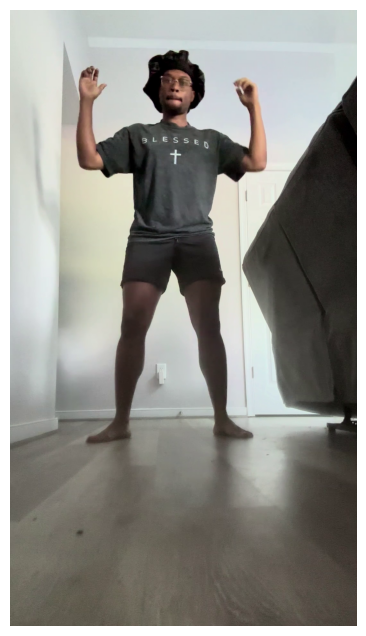

In [ ]:
import cv2
import matplotlib.pyplot as plt

video_path = "data/raw/person_02/symmetrical.mp4"

cap = cv2.VideoCapture(video_path)

#Start a little bit after 2 seconds
cap.set(cv2.CAP_PROP_POS_MSEC, 200)

ret, frame = cap.read()

print("Frame read successfully:", ret)

cap.release()

if ret:
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(12, 8))
    plt.imshow(frame_rgb)
    plt.axis("off")
    plt.show()

Find frame information

In [83]:
cap = cv2.VideoCapture(video_path)

fps = cap.get(cv2.CAP_PROP_FPS)
frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
duration = frame_count / fps

cap.release()

print("FPS:", fps)
print("Frame count:", frame_count)
print("Duration:", duration, "seconds")

FPS: 30.0
Frame count: 90
Duration: 3.0 seconds


In [65]:
import cv2

video_path = "data/raw/person_02/symmetrical.mp4"

cap = cv2.VideoCapture(video_path)

fps = cap.get(cv2.CAP_PROP_FPS)
frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
duration = frame_count / fps

print(f"FPS: {fps}")
print(f"Frame count: {frame_count}")
print(f"Duration: {duration:.2f} seconds")

for time_sec in [0, 1, 2, 2.1, 2.117, 2.2, 2.9]:
    cap.set(cv2.CAP_PROP_POS_MSEC, time_sec * 1000)
    ret, frame = cap.read()
    
    if ret:
        print(f"{time_sec:.3f}s -> frame {int(cap.get(cv2.CAP_PROP_POS_FRAMES))}")
    else:
        print(f"{time_sec:.3f}s -> could not read frame")

cap.release()

FPS: 30.0
Frame count: 90
Duration: 3.00 seconds
0.000s -> frame 1
1.000s -> frame 31
2.000s -> frame 61
2.100s -> frame 64
2.117s -> frame 65
2.200s -> frame 67
2.900s -> frame 88


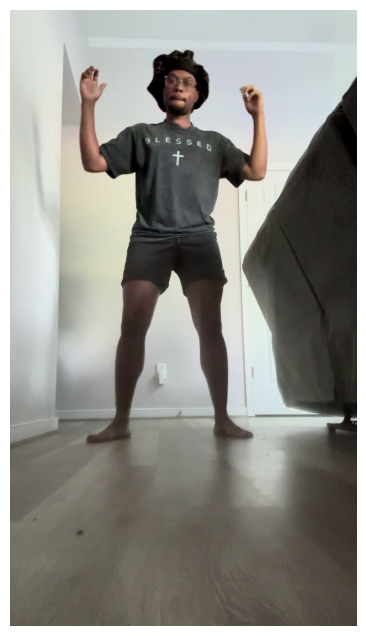

In [125]:
import cv2
import matplotlib.pyplot as plt

video_path = "data/raw/person_02/symmetrical.mp4"

cap = cv2.VideoCapture(video_path)

cap.set(cv2.CAP_PROP_POS_MSEC, 100)

ret, frame = cap.read()

cap.release()

if ret:
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(12, 8))
    plt.imshow(frame_rgb)
    plt.axis("off")
    plt.show()

  Using cached mediapipe-1.0.0-py3-none-win_amd64.whl.metadata (10 kB)
  Using cached absl_py-2.5.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached sounddevice-0.5.5-py3-none-win_amd64.whl.metadata (1.4 kB)
  Using cached cffi-2.1.1-cp311-cp311-win_amd64.whl.metadata (2.6 kB)
Using cached mediapipe-1.0.0-py3-none-win_amd64.whl (16.1 MB)
Using cached absl_py-2.5.0-py3-none-any.whl (137 kB)
Using cached sounddevice-0.5.5-py3-none-win_amd64.whl (365 kB)
Using cached cffi-2.1.1-cp311-cp311-win_amd64.whl (185 kB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: C:\Users\bluek\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


MediaPipe: 1.0.0
MediaPipe location: C:\Users\bluek\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\mediapipe\__init__.py
Has tasks: True
Tasks vision available: True


Model exists: True
Model size: 9398198 bytes


Pose Landmarker created successfully!


Create a function that will capture information such as the joint dimensions for each frame through the entire video

In [126]:
import cv2
import mediapipe as mp
import pandas as pd

video_path = "data/raw/person_02/symmetrical.mp4"

cap = cv2.VideoCapture(video_path)

START_TIME = 0.1

#Use the starting time for each frame
cap.set(cv2.CAP_PROP_POS_MSEC, START_TIME * 1000)

#Get the video information
fps = cap.get(cv2.CAP_PROP_FPS)

print("FPS:", fps)

rows = []

frame_number = 0

while True:

    #Read the next frame
    ret, frame = cap.read()

    if not ret:
        break

    #Convert the frame to color
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    #MAKE MY SKELETON
    image = mp.Image(
        image_format=mp.ImageFormat.SRGB,
        data=frame_rgb
    )

      #Find the pose
    result = landmarker.detect(image)

    #CONFIRM THE SKELETON
    if len(result.pose_landmarks) > 0:

        #GET MY SKELETON'S LANDMARKS
        landmarks = result.pose_landmarks[0]

        #Log frame information into a row representing each frame
        row = {
            "frame": frame_number,
            "time": START_TIME + (frame_number / fps)
        }

        landmark_names = {
            11: "left_shoulder",
            12: "right_shoulder",
            23: "left_hip",
            24: "right_hip",
            25: "left_knee",
            26: "right_knee",
            27: "left_ankle",
            28: "right_ankle",
            29: "left_heel",
            30: "right_heel",
            31: "left_foot_index",
            32: "right_foot_index",
        }


        #Add the SKELETON LANDMARK information
        for i, landmark in enumerate(landmarks):

            row[f"landmark_{i}_x"] = landmark.x
            row[f"landmark_{i}_y"] = landmark.y
            row[f"landmark_{i}_z"] = landmark.z
            row[f"landmark_{i}_visibility"] = landmark.visibility

            if i in landmark_names:

                name = landmark_names[i]

                row[f"{name}_x"] = landmark.x
                row[f"{name}_y"] = landmark.y
                row[f"{name}_z"] = landmark.z
                row[f"{name}_visibility"] = landmark.visibility

        rows.append(row)

    frame_number += 1

cap.release()

#Create DataFrame AFTER the loop
df = pd.DataFrame(rows)

print("Number of poses detected:", len(result.pose_landmarks))

print("DataFrame shape:", df.shape)

print(df.columns.tolist())

df.head()

FPS: 30.0
Number of poses detected: 1
DataFrame shape: (87, 182)
['frame', 'time', 'landmark_0_x', 'landmark_0_y', 'landmark_0_z', 'landmark_0_visibility', 'landmark_1_x', 'landmark_1_y', 'landmark_1_z', 'landmark_1_visibility', 'landmark_2_x', 'landmark_2_y', 'landmark_2_z', 'landmark_2_visibility', 'landmark_3_x', 'landmark_3_y', 'landmark_3_z', 'landmark_3_visibility', 'landmark_4_x', 'landmark_4_y', 'landmark_4_z', 'landmark_4_visibility', 'landmark_5_x', 'landmark_5_y', 'landmark_5_z', 'landmark_5_visibility', 'landmark_6_x', 'landmark_6_y', 'landmark_6_z', 'landmark_6_visibility', 'landmark_7_x', 'landmark_7_y', 'landmark_7_z', 'landmark_7_visibility', 'landmark_8_x', 'landmark_8_y', 'landmark_8_z', 'landmark_8_visibility', 'landmark_9_x', 'landmark_9_y', 'landmark_9_z', 'landmark_9_visibility', 'landmark_10_x', 'landmark_10_y', 'landmark_10_z', 'landmark_10_visibility', 'landmark_11_x', 'landmark_11_y', 'landmark_11_z', 'landmark_11_visibility', 'left_shoulder_x', 'left_shoulder

,frame,time,landmark_0_x,landmark_0_y,landmark_0_z,landmark_0_visibility,landmark_1_x,landmark_1_y,landmark_1_z,landmark_1_visibility,...,left_foot_index_z,left_foot_index_visibility,landmark_32_x,landmark_32_y,landmark_32_z,landmark_32_visibility,right_foot_index_x,right_foot_index_y,right_foot_index_z,right_foot_index_visibility
0,0,0.100000,0.493052,0.121832,-0.146054,0.999998,0.506130,0.112449,-0.103741,0.999991,...,-0.197023,0.966333,0.246915,0.697765,-0.264138,0.982602,0.246915,0.697765,-0.264138,0.982602
1,1,0.133333,0.492808,0.122033,-0.137396,0.999998,0.507034,0.112723,-0.092830,0.999991,...,-0.229719,0.957756,0.244671,0.698245,-0.302061,0.977893,0.244671,0.698245,-0.302061,0.977893
2,2,0.166667,0.481677,0.124535,-0.144478,0.999999,0.495491,0.113596,-0.104754,0.999993,...,-0.207970,0.971727,0.250541,0.697910,-0.220930,0.983541,0.250541,0.697910,-0.220930,0.983541
3,3,0.200000,0.480224,0.123025,-0.131969,0.999999,0.492663,0.111635,-0.091752,0.999994,...,-0.245348,0.967066,0.245594,0.699948,-0.246556,0.980376,0.245594,0.699948,-0.246556,0.980376
4,4,0.233333,0.474062,0.122946,-0.135710,0.999999,0.488199,0.110572,-0.096168,0.999995,...,-0.217626,0.969940,0.247050,0.699283,-0.241075,0.983481,0.247050,0.699283,-0.241075,0.983481


In [ ]:
import numpy as np

def calculate_angle(a, b, c):
    """
   Calculate angle ABC in degrees.
    
    a = first point
    b = vertex
    c = third point
    """

    a = np.array(a)
    b = np.array(b)
    c = np.array(c)

    ba = a - b
    bc = c - b

    cosine_angle = np.dot(ba, bc) / (
        np.linalg.norm(ba) * np.linalg.norm(bc)
    )

    cosine_angle = np.clip(cosine_angle, -1.0, 1.0)

    angle = np.degrees(np.arccos(cosine_angle))

    return angle

Test right and left knee angles to confirm the angle function works

In [127]:
row = df.iloc[0]

left_knee_angle = calculate_angle(
    [
        row["left_hip_x"],
        row["left_hip_y"],
        row["left_hip_z"]
    ],
    [
        row["left_knee_x"],
        row["left_knee_y"],
        row["left_knee_z"]
    ],
    [
        row["left_ankle_x"],
        row["left_ankle_y"],
        row["left_ankle_z"]
    ]
)

print("Left knee angle:", left_knee_angle)

Left knee angle: 143.91511064005678


In [128]:
right_knee_angle = calculate_angle(
    [
        row["right_hip_x"],
        row["right_hip_y"],
        row["right_hip_z"]
    ],
    [
        row["right_knee_x"],
        row["right_knee_y"],
        row["right_knee_z"]
    ],
    [
        row["right_ankle_x"],
        row["right_ankle_y"],
        row["right_ankle_z"]
    ]
)

print("Right knee angle:", right_knee_angle)

Right knee angle: 139.73603317503844


Now make that equation for an array so it can apply to an entire video of frames and then apply it to all the joints again

In [129]:
import numpy as np

def calculate_angle(a, b, c):
    a = np.array(a)
    b = np.array(b)
    c = np.array(c)

    ba = a - b
    bc = c - b

    cosine_angle = np.dot(ba, bc) / (
        np.linalg.norm(ba) * np.linalg.norm(bc)
    )

    cosine_angle = np.clip(cosine_angle, -1.0, 1.0)

    return np.degrees(np.arccos(cosine_angle))

Joint Angles

In [130]:
#KNEES
df["left_knee_angle"] = df.apply(
    lambda row: calculate_angle(
        [row["left_hip_x"], row["left_hip_y"], row["left_hip_z"]],
        [row["left_knee_x"], row["left_knee_y"], row["left_knee_z"]],
        [row["left_ankle_x"], row["left_ankle_y"], row["left_ankle_z"]]
    ),
    axis=1
)

df["right_knee_angle"] = df.apply(
    lambda row: calculate_angle(
        [row["right_hip_x"], row["right_hip_y"], row["right_hip_z"]],
        [row["right_knee_x"], row["right_knee_y"], row["right_knee_z"]],
        [row["right_ankle_x"], row["right_ankle_y"], row["right_ankle_z"]]
    ),
    axis=1
)

#HIPS
df["left_hip_angle"] = df.apply(
    lambda row: calculate_angle(
        [row["left_shoulder_x"], row["left_shoulder_y"], row["left_shoulder_z"]],
        [row["left_hip_x"], row["left_hip_y"], row["left_hip_z"]],
        [row["left_knee_x"], row["left_knee_y"], row["left_knee_z"]]
    ),
    axis=1
)

df["right_hip_angle"] = df.apply(
    lambda row: calculate_angle(
        [row["right_shoulder_x"], row["right_shoulder_y"], row["right_shoulder_z"]],
        [row["right_hip_x"], row["right_hip_y"], row["right_hip_z"]],
        [row["right_knee_x"], row["right_knee_y"], row["right_knee_z"]]
    ),
    axis=1
)

#ANKLES
df["left_ankle_angle"] = df.apply(
    lambda row: calculate_angle(
        [row["left_knee_x"], row["left_knee_y"], row["left_knee_z"]],
        [row["left_ankle_x"], row["left_ankle_y"], row["left_ankle_z"]],
        [row["left_foot_index_x"], row["left_foot_index_y"], row["left_foot_index_z"]]
    ),
    axis=1
)

df["right_ankle_angle"] = df.apply(
    lambda row: calculate_angle(
        [row["right_knee_x"], row["right_knee_y"], row["right_knee_z"]],
        [row["right_ankle_x"], row["right_ankle_y"], row["right_ankle_z"]],
        [row["right_foot_index_x"], row["right_foot_index_y"], row["right_foot_index_z"]]
    ),
    axis=1
)

df[["frame", "time", "left_knee_angle", "right_knee_angle", "left_hip_angle", "right_hip_angle",
    "left_ankle_angle", "right_ankle_angle",]].head(10)

,frame,time,left_knee_angle,right_knee_angle,left_hip_angle,right_hip_angle,left_ankle_angle,right_ankle_angle
0,0,0.100000,143.915111,139.736033,151.693099,152.351517,88.361679,91.402892
1,1,0.133333,145.828732,139.716976,155.156968,154.869562,97.025900,96.043513
2,2,0.166667,150.597399,147.994027,150.650160,151.747258,91.175224,94.739455
3,3,0.200000,148.710855,142.131437,154.165226,152.227840,98.666382,91.708635
4,4,0.233333,149.534748,142.689306,150.160078,152.527117,93.558251,93.011111
5,5,0.266667,148.714411,144.391308,151.081624,152.793930,93.414446,95.915398
6,6,0.300000,139.348820,133.557427,153.716271,150.724015,83.217901,85.004811
7,7,0.333333,132.405033,124.701621,155.329176,150.571042,78.688355,78.235323
8,8,0.366667,107.557580,106.403711,149.769985,135.791932,64.477096,59.292145
9,9,0.400000,90.985942,98.758152,107.203951,105.910216,54.385076,53.613417


Show the joint angle for the knees over the entire video

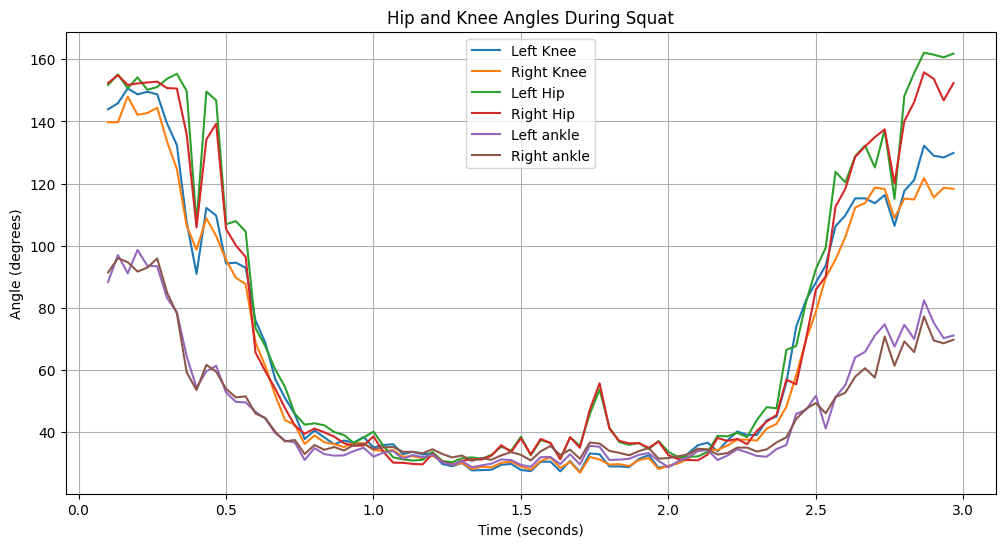

In [150]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.plot(
    df["time"],
    df["left_knee_angle"],
    label="Left Knee"
)

plt.plot(
    df["time"],
    df["right_knee_angle"],
    label="Right Knee"
)

plt.plot(
    df["time"],
    df["left_hip_angle"],
    label="Left Hip"
)

plt.plot(
    df["time"],
    df["right_hip_angle"],
    label="Right Hip"
)

plt.plot(
    df["time"],
    df["left_ankle_angle"],
    label="Left ankle"
)

plt.plot(
    df["time"],
    df["right_ankle_angle"],
    label="Right ankle"
)

plt.xlabel("Time (seconds)")
plt.ylabel("Angle (degrees)")
plt.title("Hip and Knee Angles During Squat")
plt.legend()
plt.grid(True)

plt.show()

Calculate the actual difference to see what the real difference in angles for both knees are

In [151]:
df["knee_angle_difference"] = (
    df["left_knee_angle"] -
    df["right_knee_angle"]
)

df["knee_angle_difference_abs"] = (
    df["knee_angle_difference"].abs()
)

print(
    "Mean absolute knee angle difference:",
    df["knee_angle_difference_abs"].mean()
)

print(
    "Maximum knee angle difference:",
    df["knee_angle_difference_abs"].max()
)

Mean absolute knee angle difference: 3.353102727774148
Maximum knee angle difference: 15.598383447994323


Calculate the range of motion for each joint

In [ ]:
#Knee ROM
left_knee_rom = (
    df["left_knee_angle"].max() -
    df["left_knee_angle"].min()
)

right_knee_rom = (
    df["right_knee_angle"].max() -
    df["right_knee_angle"].min()
)

#Hip ROM
left_hip_rom = (
    df["left_hip_angle"].max() -
    df["left_hip_angle"].min()
)

right_hip_rom = (
    df["right_hip_angle"].max() -
    df["right_hip_angle"].min()
)

#Ankle ROM
left_ankle_rom = (
    df["left_ankle_angle"].max() -
    df["left_ankle_angle"].min()
)

right_ankle_rom = (
    df["right_ankle_angle"].max() -
    df["right_ankle_angle"].min()
)

print("Left knee ROM:", left_knee_rom)
print("Right knee ROM:", right_knee_rom)
print("")
print("Left hip ROM:", left_hip_rom)
print("Right hip ROM:", right_hip_rom)
print("")
print("Left ankle ROM:", left_ankle_rom)
print("Right ankle ROM:", right_ankle_rom)
print("")
print(
    "Knee ROM difference:",
    abs(left_knee_rom - right_knee_rom)
)

print(
    "Hip ROM difference:",
    abs(left_hip_rom - right_hip_rom)
)

print(
    "Ankle ROM difference:",
    abs(left_ankle_rom - right_ankle_rom)
)

Left knee ROM: 123.35234921535401
Right knee ROM: 120.96667337009119

Left hip ROM: 131.7010220293339
Right hip ROM: 126.25595054886092

Left ankle ROM: 69.86654075788789
Right ankle ROM: 65.18388317383412

Knee ROM difference: 2.385675845262824
Hip ROM difference: 5.445071480472976
Ankle ROM difference: 4.682657584053771


Normalized Assymetry

In [134]:
def asymmetry_percentage(left, right):
    return (
        abs(left - right) /
        ((left + right) / 2)
    ) * 100

knee_rom_asymmetry = asymmetry_percentage(
    left_knee_rom,
    right_knee_rom
)

hip_rom_asymmetry = asymmetry_percentage(
    left_hip_rom,
    right_hip_rom
)

ankle_rom_asymmetry = asymmetry_percentage(
    left_ankle_rom,
    right_ankle_rom
)

print("Knee ROM asymmetry:", knee_rom_asymmetry, "%")
print("Hip ROM asymmetry:", hip_rom_asymmetry, "%")
print("Ankle ROM asymmetry:", ankle_rom_asymmetry, "%")

Knee ROM asymmetry: 1.9529186225591473 %
Hip ROM asymmetry: 4.221689707435533 %
Ankle ROM asymmetry: 6.93468031825091 %


Display the hip knee and ankle angles during the squat


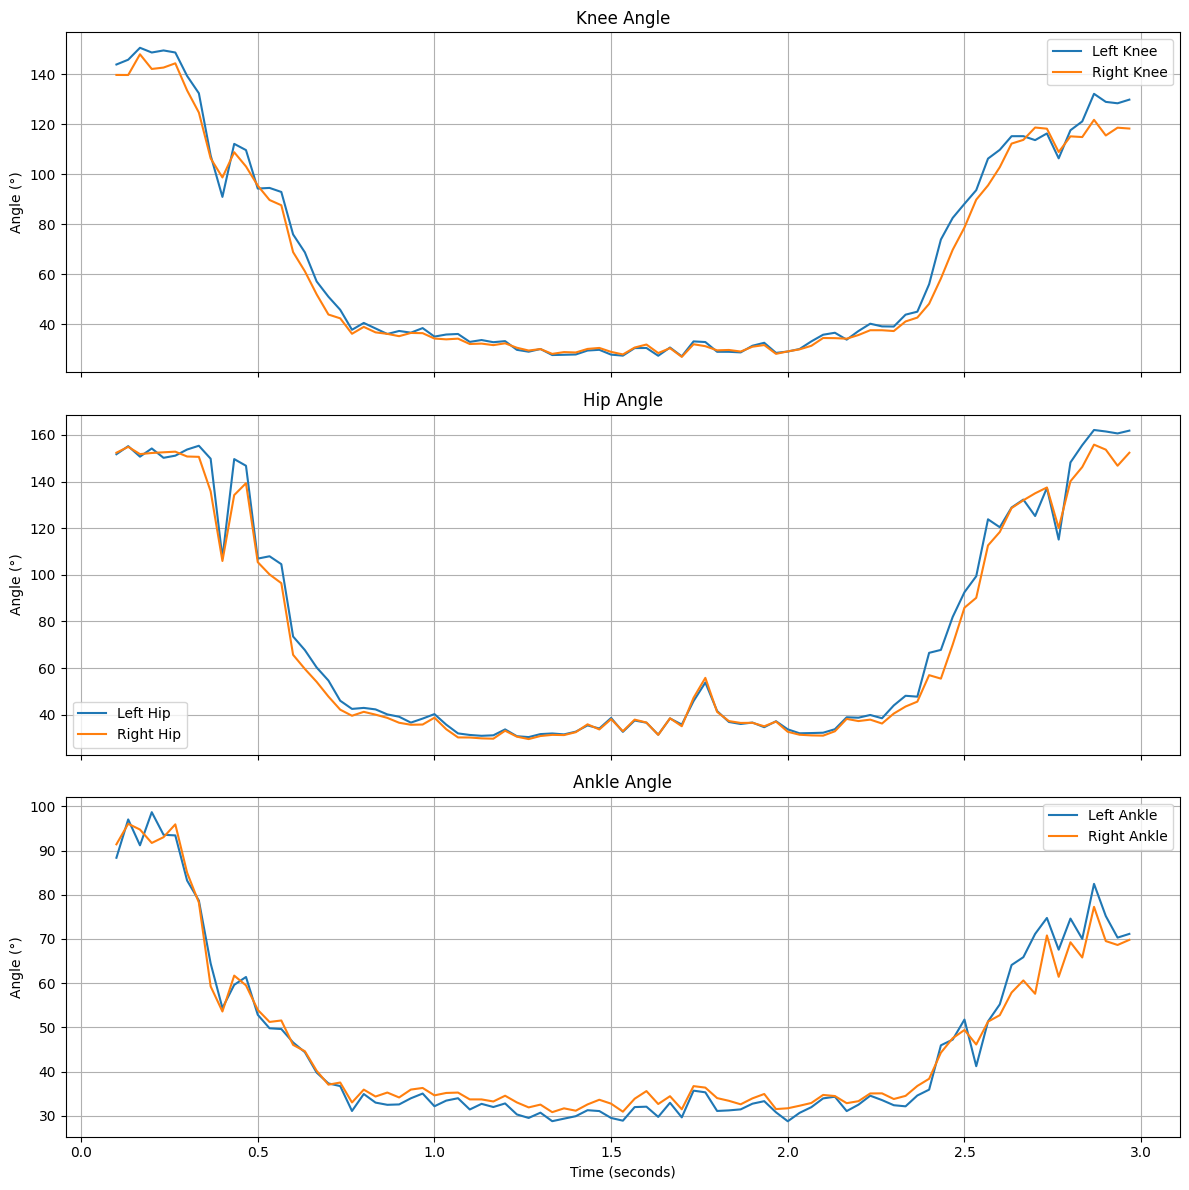

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 1, figsize=(12, 12), sharex=True)

# Knee
axes[0].plot(
    df["time"],
    df["left_knee_angle"],
    label="Left Knee"
)

axes[0].plot(
    df["time"],
    df["right_knee_angle"],
    label="Right Knee"
)

axes[0].set_ylabel("Angle (°)")
axes[0].set_title("Knee Angle")
axes[0].legend()
axes[0].grid(True)

# Hip
axes[1].plot(
    df["time"],
    df["left_hip_angle"],
    label="Left Hip"
)

axes[1].plot(
    df["time"],
    df["right_hip_angle"],
    label="Right Hip"
)

axes[1].set_ylabel("Angle (°)")
axes[1].set_title("Hip Angle")
axes[1].legend()
axes[1].grid(True)

# Ankle
axes[2].plot(
    df["time"],
    df["left_ankle_angle"],
    label="Left Ankle"
)

axes[2].plot(
    df["time"],
    df["right_ankle_angle"],
    label="Right Ankle"
)

axes[2].set_xlabel("Time (seconds)")
axes[2].set_ylabel("Angle (°)")
axes[2].set_title("Ankle Angle")
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.show()

Identify which coordinate is the verical axis for the trunk to confirm which coordinate to measure (Which is the Y coordinate in this case)

In [137]:
print(df[[
    "left_shoulder_x",
    "left_shoulder_y",
    "left_shoulder_z",
    "left_hip_x",
    "left_hip_y",
    "left_hip_z"
]].head())

print(df[[
    "right_shoulder_x",
    "right_shoulder_y",
    "right_shoulder_z",
    "right_hip_x",
    "right_hip_y",
    "right_hip_z"
]].head())

   left_shoulder_x  left_shoulder_y  left_shoulder_z  left_hip_x  left_hip_y  \
0         0.603951         0.213742         0.119842    0.549644    0.380336   
1         0.601893         0.212512         0.130078    0.547866    0.379842   
2         0.599792         0.212464         0.104598    0.544518    0.380300   
3         0.598535         0.209974         0.136638    0.546073    0.377074   
4         0.596841         0.207992         0.131694    0.542539    0.379379   

   left_hip_z  
0    0.008446  
1    0.010214  
2   -0.002902  
3    0.005300  
4   -0.001117  
   right_shoulder_x  right_shoulder_y  right_shoulder_z  right_hip_x  \
0          0.375512          0.202614          0.111711     0.410155   
1          0.373314          0.203811          0.116300     0.408784   
2          0.371161          0.201747          0.109912     0.406498   
3          0.367641          0.200865          0.132197     0.405382   
4          0.366242          0.199412          0.139224     0.4

Calculate the torso center points with a hip and shoulder center point

In [139]:
import numpy as np

df["shoulder_center_x"] = (
    df["left_shoulder_x"] +
    df["right_shoulder_x"]
) / 2

df["shoulder_center_y"] = (
    df["left_shoulder_y"] +
    df["right_shoulder_y"]
) / 2

df["shoulder_center_z"] = (
    df["left_shoulder_z"] +
    df["right_shoulder_z"]
) / 2


df["hip_center_x"] = (
    df["left_hip_x"] +
    df["right_hip_x"]
) / 2

df["hip_center_y"] = (
    df["left_hip_y"] +
    df["right_hip_y"]
) / 2

df["hip_center_z"] = (
    df["left_hip_z"] +
    df["right_hip_z"]
) / 2

df[[
    "shoulder_center_x",
    "shoulder_center_y",
    "shoulder_center_z",
    "hip_center_x",
    "hip_center_y",
    "hip_center_z"
]].head()

,shoulder_center_x,shoulder_center_y,shoulder_center_z,hip_center_x,hip_center_y,hip_center_z
0,0.489731,0.208178,0.115777,0.479899,0.377453,-0.000216
1,0.487603,0.208161,0.123189,0.478325,0.376351,-0.000224
2,0.485476,0.207105,0.107255,0.475508,0.377983,-0.000289
3,0.483088,0.205419,0.134417,0.475728,0.374502,-0.000254
4,0.481542,0.203702,0.135459,0.473181,0.376487,-0.000228


Calculate the trunk lean using the Y coordinate to calculate a vector from the hip center to the shoulder center 

In [146]:
df["trunk_vector_x"] = (
    df["shoulder_center_x"] -
    df["hip_center_x"]
)

df["trunk_vector_y"] = (
    df["shoulder_center_y"] -
    df["hip_center_y"]
)

df["trunk_vector_z"] = (
    df["shoulder_center_z"] -
    df["hip_center_z"]
)

#The smaller the Y coordinate, the higher the position, so an upright hip-to-shoulder vector creates a negative Y.
vertical = np.array([0, -1, 0])

In [ ]:
def vector_angle(v1, v2):
 
    v1 = np.array(v1)
    v2 = np.array(v2)

    cosine_angle = np.dot(v1, v2) / (
        np.linalg.norm(v1) * np.linalg.norm(v2)
    )

    cosine_angle = np.clip(cosine_angle, -1.0, 1.0)

    return np.degrees(np.arccos(cosine_angle))

In [148]:
df["trunk_angle"] = df.apply(
    lambda row: vector_angle(
        [
            row["trunk_vector_x"],
            row["trunk_vector_y"],
            row["trunk_vector_z"]
        ],
        vertical
    ),
    axis=1
)

df["trunk_angle"].head()

0    34.515934
1    36.347198
2    32.295397
3    38.578530
4    38.194936
Name: trunk_angle, dtype: float64

Display the trunk angle during the squaat

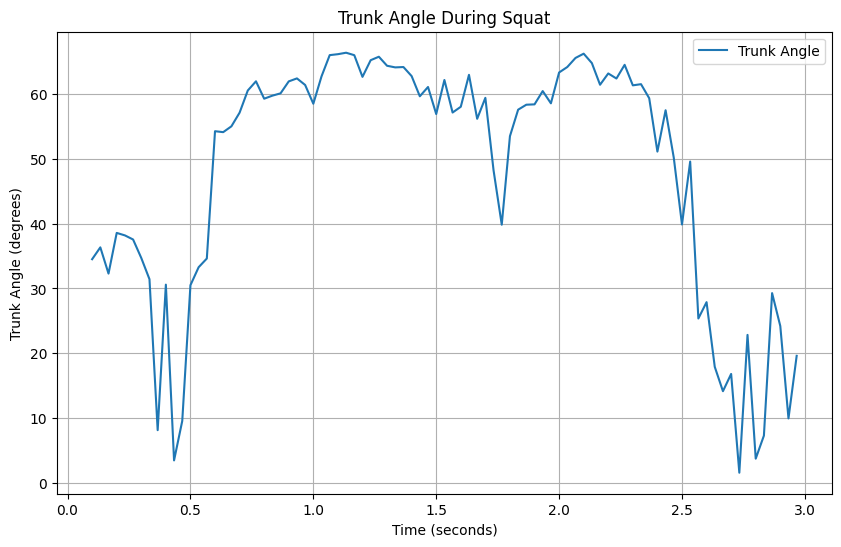

In [149]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.plot(
    df["time"],
    df["trunk_angle"],
    label="Trunk Angle"
)

plt.xlabel("Time (seconds)")
plt.ylabel("Trunk Angle (degrees)")
plt.title("Trunk Angle During Squat")
plt.legend()
plt.grid(True)

plt.show()

Calculate the velocity of each joint

In [ ]:
df["left_knee_angular_velocity"] = (
    df["left_knee_angle"].diff() /
    df["time"].diff()
)

df["right_knee_angular_velocity"] = (
    df["right_knee_angle"].diff() /
    df["time"].diff()
)

df["left_hip_angular_velocity"] = (
    df["left_hip_angle"].diff() /
    df["time"].diff()
)

df["right_hip_angular_velocity"] = (
    df["right_hip_angle"].diff() /
    df["time"].diff()
)

df["left_ankle_angular_velocity"] = (
    df["left_ankle_angle"].diff() /
    df["time"].diff()
)

df["right_ankle_angular_velocity"] = (
    df["right_ankle_angle"].diff() /
    df["time"].diff()
)

df["trunk_angular_velocity"] = (
    df["trunk_angle"].diff() /
    df["time"].diff()
)

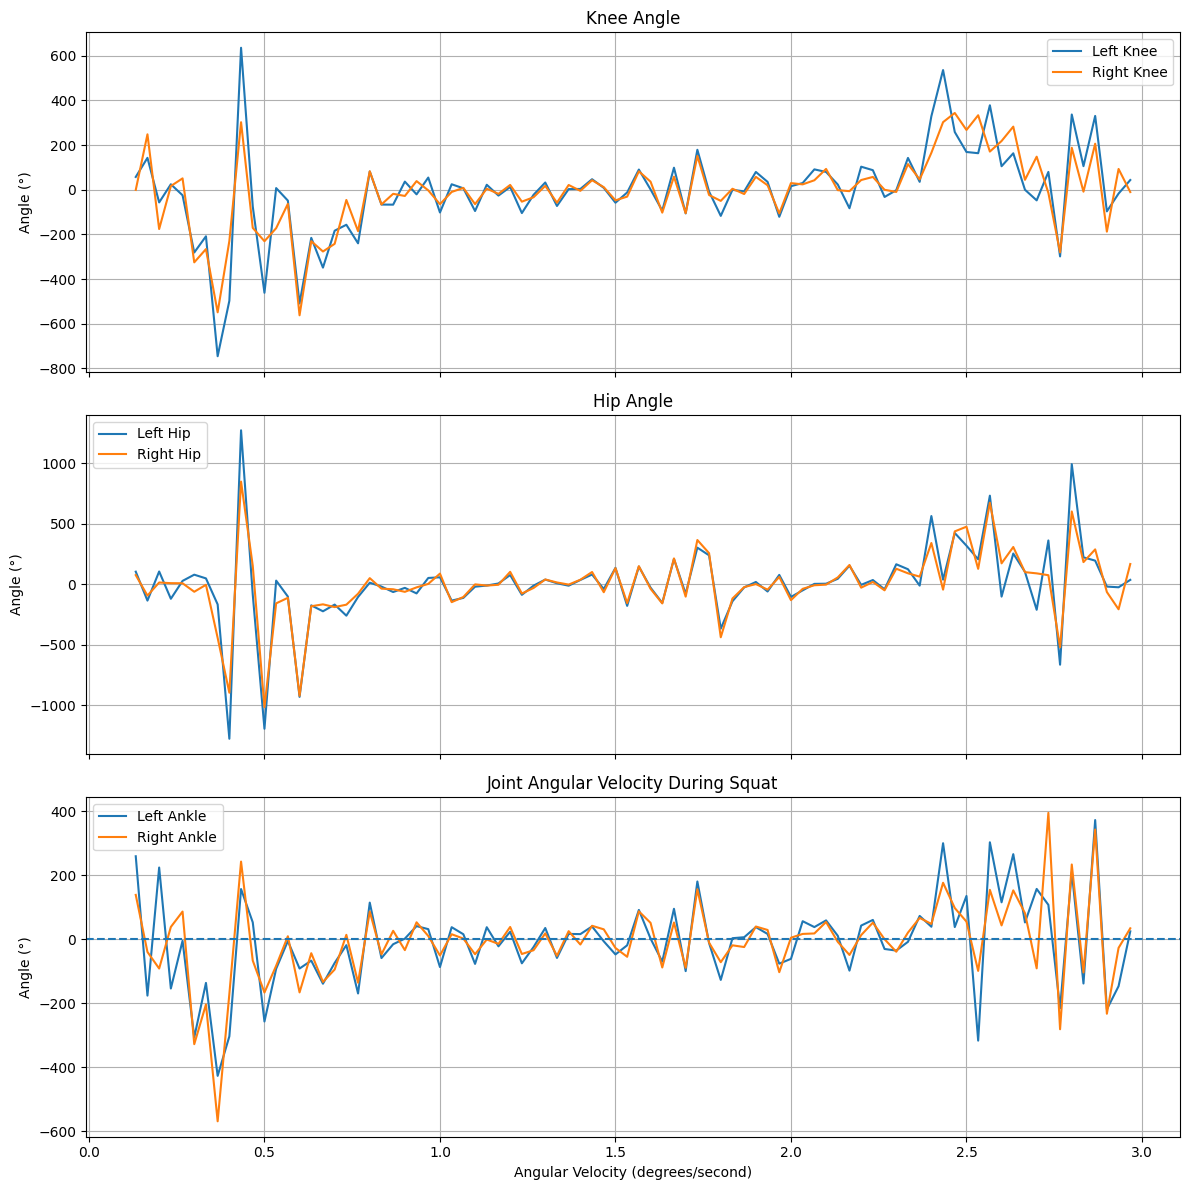

In [153]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 1, figsize=(12, 12), sharex=True)

# Knee
axes[0].plot(
    df["time"],
    df["left_knee_angular_velocity"],
    label="Left Knee"
)

axes[0].plot(
    df["time"],
    df["right_knee_angular_velocity"],
    label="Right Knee"
)

axes[0].set_ylabel("Angle (°)")
axes[0].set_title("Knee Angle")
axes[0].legend()
axes[0].grid(True)

# Hip
axes[1].plot(
    df["time"],
    df["left_hip_angular_velocity"],
    label="Left Hip"
)

axes[1].plot(
    df["time"],
    df["right_hip_angular_velocity"],
    label="Right Hip"
)

axes[1].set_ylabel("Angle (°)")
axes[1].set_title("Hip Angle")
axes[1].legend()
axes[1].grid(True)

# Ankle
axes[2].plot(
    df["time"],
    df["left_ankle_angular_velocity"],
    label="Left Ankle"
)

axes[2].plot(
    df["time"],
    df["right_ankle_angular_velocity"],
    label="Right Ankle"
)

axes[2].set_xlabel("Angular Velocity (degrees/second)")
axes[2].set_ylabel("Angle (°)")
axes[2].set_title("Ankle Angle")
axes[2].legend()
axes[2].grid(True)

plt.axhline(0, linestyle="--")
plt.title("Joint Angular Velocity During Squat")
plt.legend()
plt.tight_layout()
plt.show()

Create a function that will calculate asymmetry

In [191]:
def calculate_asymmetry(left_value, right_value):
    average = (left_value + right_value) / 2

    if average == 0:
        return 0

    return abs(left_value - right_value) / average * 100

Extract the velocity measurements into features

In [ ]:
features = {
    "left_knee_peak_velocity": df["left_knee_angular_velocity"].abs().max(),
    "right_knee_peak_velocity": df["right_knee_angular_velocity"].abs().max(),

    "left_hip_peak_velocity": df["left_hip_angular_velocity"].abs().max(),
    "right_hip_peak_velocity": df["right_hip_angular_velocity"].abs().max(),

    "left_ankle_peak_velocity": df["left_ankle_angular_velocity"].abs().max(),
    "right_ankle_peak_velocity": df["right_ankle_angular_velocity"].abs().max(),
}

features["knee_peak_velocity_asymmetry"] = asymmetry_percentage(
    features["left_knee_peak_velocity"],
    features["right_knee_peak_velocity"]
)

features["hip_peak_velocity_asymmetry"] = asymmetry_percentage(
    features["left_hip_peak_velocity"],
    features["right_hip_peak_velocity"]
)

features["ankle_peak_velocity_asymmetry"] = asymmetry_percentage(
    features["left_ankle_peak_velocity"],
    features["right_ankle_peak_velocity"]
)

Create the feature vector

In [161]:
features = {
    #Knee rom
    "left_knee_rom": left_knee_rom,
    "right_knee_rom": right_knee_rom,
    "knee_rom_asymmetry": knee_rom_asymmetry,

    #Hip rom
    "left_hip_rom": left_hip_rom,
    "right_hip_rom": right_hip_rom,
    "hip_rom_asymmetry": hip_rom_asymmetry,

    #Ankle rom
    "left_ankle_rom": left_ankle_rom,
    "right_ankle_rom": right_ankle_rom,
    "ankle_rom_asymmetry": ankle_rom_asymmetry,

    #Knee velocity
    "left_knee_peak_velocity": df["left_knee_angular_velocity"].abs().max(),
    "right_knee_peak_velocity": df["right_knee_angular_velocity"].abs().max(),

    #Hip velocity
    "left_hip_peak_velocity": df["left_hip_angular_velocity"].abs().max(),
    "right_hip_peak_velocity": df["right_hip_angular_velocity"].abs().max(),

    #Ankle velocity
    "left_ankle_peak_velocity": df["left_ankle_angular_velocity"].abs().max(),
    "right_ankle_peak_velocity": df["right_ankle_angular_velocity"].abs().max(),

    #Trunk
    "max_trunk_angle": df["trunk_angle"].max(), "trunk_rom": (
        df["trunk_angle"].max() - df["trunk_angle"].min()
    )
}

feature_df = pd.DataFrame([features])

feature_df.head()

,left_knee_rom,right_knee_rom,knee_rom_asymmetry,left_hip_rom,right_hip_rom,hip_rom_asymmetry,left_ankle_rom,right_ankle_rom,ankle_rom_asymmetry,left_knee_peak_velocity,right_knee_peak_velocity,left_hip_peak_velocity,right_hip_peak_velocity,left_ankle_peak_velocity,right_ankle_peak_velocity,max_trunk_angle,trunk_rom
0,123.352349,120.966673,1.952919,131.701022,126.255951,4.22169,69.866541,65.183883,6.93468,745.423589,562.136632,1276.981012,1015.659519,426.337782,568.295336,66.406593,64.864962


In [98]:
landmarks = result.pose_landmarks[0]

print("Number of landmarks:", len(landmarks))

print("Frames processed:", frame_number)
print("Frames with pose:", len(df))

Number of landmarks: 33
Frames processed: 69
Frames with pose: 69


In [89]:
for i, landmark in enumerate(landmarks[:5]):
    print(
        i,
        "x:", round(landmark.x, 4),
        "y:", round(landmark.y, 4),
        "z:", round(landmark.z, 4),
        "visibility:", round(landmark.visibility, 4)
    )

0 x: 0.4599 y: 0.1408 z: -0.7034 visibility: 1.0
1 x: 0.4714 y: 0.129 z: -0.6457 visibility: 1.0
2 x: 0.4786 y: 0.1298 z: -0.6455 visibility: 1.0
3 x: 0.4857 y: 0.1307 z: -0.6456 visibility: 1.0
4 x: 0.4494 y: 0.1286 z: -0.6481 visibility: 1.0


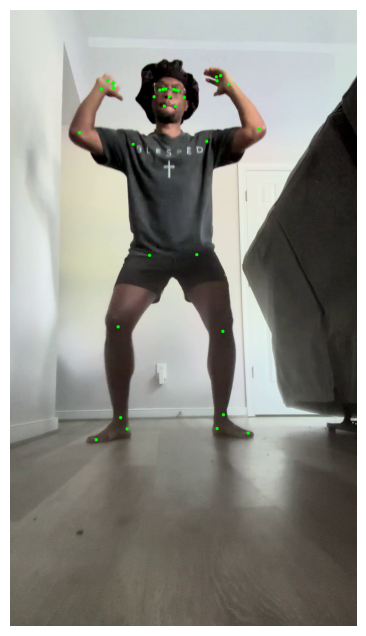

In [91]:
import cv2
import mediapipe as mp
import matplotlib.pyplot as plt

video_path = "data/raw/person_02/symmetrical.mp4"

cap = cv2.VideoCapture(video_path)

cap.set(cv2.CAP_PROP_POS_MSEC, 700)

ret, frame = cap.read()
cap.release()

if not ret:
    raise RuntimeError("Could not read video frame.")

frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

image = mp.Image(
    image_format=mp.ImageFormat.SRGB,
    data=frame_rgb
)

result = landmarker.detect(image)

#Copy the frame
annotated = frame_rgb.copy()

#Create the landmarks manually
landmarks = result.pose_landmarks[0]

height, width, _ = annotated.shape

for landmark in landmarks:
    x = int(landmark.x * width)
    y = int(landmark.y * height)

    cv2.circle(
        annotated,
        (x, y),
        5,
        (0, 255, 0),
        -1
    )

plt.figure(figsize=(12, 8))
plt.imshow(annotated)
plt.axis("off")
plt.show()

In [92]:
pose_landmark = mp.tasks.vision.PoseLandmark

landmark_names = {
    "left_shoulder": pose_landmark.LEFT_SHOULDER,
    "right_shoulder": pose_landmark.RIGHT_SHOULDER,
    "left_hip": pose_landmark.LEFT_HIP,
    "right_hip": pose_landmark.RIGHT_HIP,
    "left_knee": pose_landmark.LEFT_KNEE,
    "right_knee": pose_landmark.RIGHT_KNEE,
    "left_ankle": pose_landmark.LEFT_ANKLE,
    "right_ankle": pose_landmark.RIGHT_ANKLE,
}

for name, index in landmark_names.items():
    print(name, index)

left_shoulder 11
right_shoulder 12
left_hip 23
right_hip 24
left_knee 25
right_knee 26
left_ankle 27
right_ankle 28


In [93]:
START_TIME = 0
END_TIME = 2.9

In [94]:
world_landmarks = result.pose_world_landmarks[0]

print("Number of world landmarks:", len(world_landmarks))

for name, index in landmark_names.items():
    landmark = world_landmarks[index]
    
    print(
        name,
        "x:", round(landmark.x, 4),
        "y:", round(landmark.y, 4),
        "z:", round(landmark.z, 4)
    )

Number of world landmarks: 33
left_shoulder x: 0.1452 y: -0.4919 z: -0.1176
right_shoulder x: -0.1579 y: -0.478 z: -0.1281
left_hip x: 0.1058 y: -0.0029 z: 0.0039
right_hip x: -0.106 y: 0.0026 z: -0.0026
left_knee x: 0.1883 y: 0.3668 z: -0.1167
right_knee x: -0.2249 y: 0.3498 z: -0.1315
left_ankle x: 0.233 y: 0.7053 z: -0.0311
right_ankle x: -0.2082 y: 0.715 z: -0.032


In [49]:
import mediapipe as mp

mp_pose = mp.solutions.pose
mp_drawing = mp.solutions.drawing_utils

pose = mp_pose.Pose(
    static_image_mode=True,
    model_complexity=2,
    min_detection_confidence=0.5
)

print("MediaPipe Pose initialized successfully!")

AttributeError: module 'mediapipe' has no attribute 'solutions'